In [ ]:
# ============================================================
# STEAM GAMES ANALYTICS — CONSULTORA DE VIDEOJUEGOS
# Ciencia de Datos | Dataset: Top 500 juegos de Steam
# ============================================================

# ============================================================
# BLOQUE 0 — LIBRERÍAS E IMPORTACIÓN DEL DATASET
# ============================================================
# Por qué está acá: todo notebook arranca importando las
# herramientas y cargando los datos. Es la base de todo.

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter

def currency_formatter(x, pos):
    if x >= 1e9:
        return f'${x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    else:
        return f'${x:.0f}'

def player_formatter(x, pos):
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K'
    else:
        return f'{x:.0f}'

uploaded = files.upload()
df = pd.read_csv("steam_games_500_2026 (1).csv", encoding='latin1', sep=';', decimal=',')

print("Dataset cargado correctamente")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(df.columns.tolist())

Saving steam_games_500_2026 (1).csv to steam_games_500_2026 (1).csv
Dataset cargado correctamente
Filas: 500 | Columnas: 11
['AppID', 'Name', 'Release_Date', 'Primary_Genre', 'All_Tags', 'Price_USD', 'Review_Score_Pct_SteamDB', 'Total_Reviews', 'Estimated_Owners', '24h_Peak_Players', 'ADPC']


In [ ]:
# ============================================================
# BLOQUE 1 — LIMPIEZA Y PREPARACIÓN DEL DATASET
# ============================================================
# Por qué está acá: los datos crudos siempre tienen problemas.
# Este bloque toma decisiones explícitas sobre qué incluir y
# qué no, y las justifica. Así el análisis siguiente es confiable.
#
# Preguntas que responde:
#   - ¿Qué tan completo es el dataset?
#   - ¿Cómo manejamos los juegos gratis (Price = 0)?
#   - ¿Qué hacemos con juegos sin reviews?

# Definición de ARPU base por género
ARPU_base = {"Action": 13, "Adventure": 9, "RPG": 20, "Strategy": 13, "Simulation": 8, "Casual": 6, "Massively Multiplayer": 22, "Indie": 7, "Sports": 11, "Racing": 9, "Unknown": 10}

# Crear la columna ARPU en el DataFrame principal 'df'
df['ARPU'] = df['Primary_Genre'].map(ARPU_base)

# Si algún género no estuviera en ARPU_base, su ARPU se establecería en NaN.
# Por seguridad, podemos llenar esos valores con el ARPU de 'Unknown'.
df['ARPU'].fillna(value=ARPU_base['Unknown'], inplace=True)

print("=== ANÁLISIS DE VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== DISTRIBUCIÓN DE PRECIOS ===")
print(f"Juegos gratuitos (Price = 0): {(df['Price_USD'] == 0).sum()}")
print(f"Juegos de pago (Price > 0):   {(df['Price_USD'] > 0).sum()}")
print(f"Juegos sin reviews:           {(df['Total_Reviews'] == 0).sum()}")

# --- Decisión de limpieza ---
# Para el análisis de revenue, creamos una columna 'Revenue' que considera:
# - Para juegos de pago: Estimated_Owners * Price_USD * (1 - ADPC) (Net Revenue)
# - Para juegos gratuitos: Estimated_Owners * ARPU (promedio de revenue por usuario)
# Filtramos para incluir solo juegos que tienen al menos una review.

juegos_de_pago = df[df['Price_USD'] > 0].copy()

# Crear un DataFrame para el análisis de revenue que incluya todos los juegos con reviews
df_revenue_analysis = df[df['Total_Reviews'] > 0].copy()

# Calcular la columna 'Revenue' en este nuevo DataFrame
df_revenue_analysis['Revenue'] = df_revenue_analysis.apply(
    lambda row: (row['Estimated_Owners'] * row['Price_USD'] * (1 - row['ADPC'])) if row['Price_USD'] > 0
    else row['Estimated_Owners'] * row['ARPU'],
    axis=1
)

# Actualizar 'juegos_con_revenue' para que apunte a este nuevo DataFrame
juegos_con_revenue = df_revenue_analysis

print(f"\nDataset para análisis de revenue: {juegos_con_revenue.shape[0]} juegos")

=== ANÁLISIS DE VALORES NULOS ===
AppID                       0
Name                        0
Release_Date                0
Primary_Genre               0
All_Tags                    0
Price_USD                   0
Review_Score_Pct_SteamDB    0
Total_Reviews               0
Estimated_Owners            0
24h_Peak_Players            0
ADPC                        0
ARPU                        0
dtype: int64

=== DISTRIBUCIÓN DE PRECIOS ===
Juegos gratuitos (Price = 0): 62
Juegos de pago (Price > 0):   438
Juegos sin reviews:           3

Dataset para análisis de revenue: 497 juegos


/tmp/ipykernel_1554/2211675155.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ARPU'].fillna(value=ARPU_base['Unknown'], inplace=True)


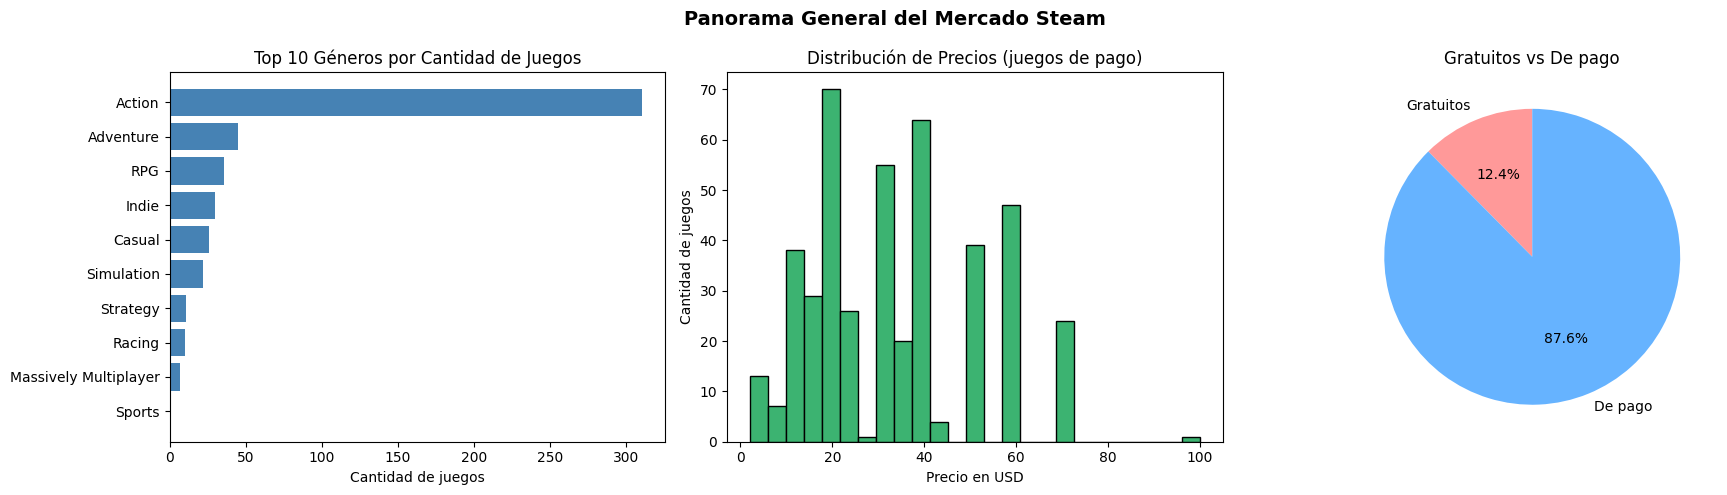

In [ ]:
# ============================================================
# BLOQUE 2 — PANORAMA GENERAL DEL MERCADO
# ============================================================
# Por qué está acá: antes de recomendar cualquier estrategia,
# una consultora necesita entender el terreno. Este bloque
# responde las preguntas básicas de contexto.
#
# Preguntas que responde:
#   - ¿Qué géneros dominan el mercado en cantidad?
#   - ¿Cómo se distribuyen los precios?
#   - ¿Qué tan grande es el mercado de juegos gratis vs de pago?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Panorama General del Mercado Steam', fontsize=14, fontweight='bold')

# Gráfico 1: Top géneros por cantidad
top_generos = df['Primary_Genre'].value_counts().head(10)
axes[0].barh(top_generos.index[::-1], top_generos.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Géneros por Cantidad de Juegos')
axes[0].set_xlabel('Cantidad de juegos')

# Gráfico 2: Distribución de precios (solo de pago)
axes[1].hist(juegos_de_pago['Price_USD'], bins=25, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Distribución de Precios (juegos de pago)')
axes[1].set_xlabel('Precio en USD')
axes[1].set_ylabel('Cantidad de juegos')

# Gráfico 3: Gratis vs de pago
gratis = (df['Price_USD'] == 0).sum()
de_pago = (df['Price_USD'] > 0).sum()
axes[2].pie([gratis, de_pago], labels=['Gratuitos', 'De pago'],
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
axes[2].set_title('Gratuitos vs De pago')

plt.tight_layout()
plt.show()

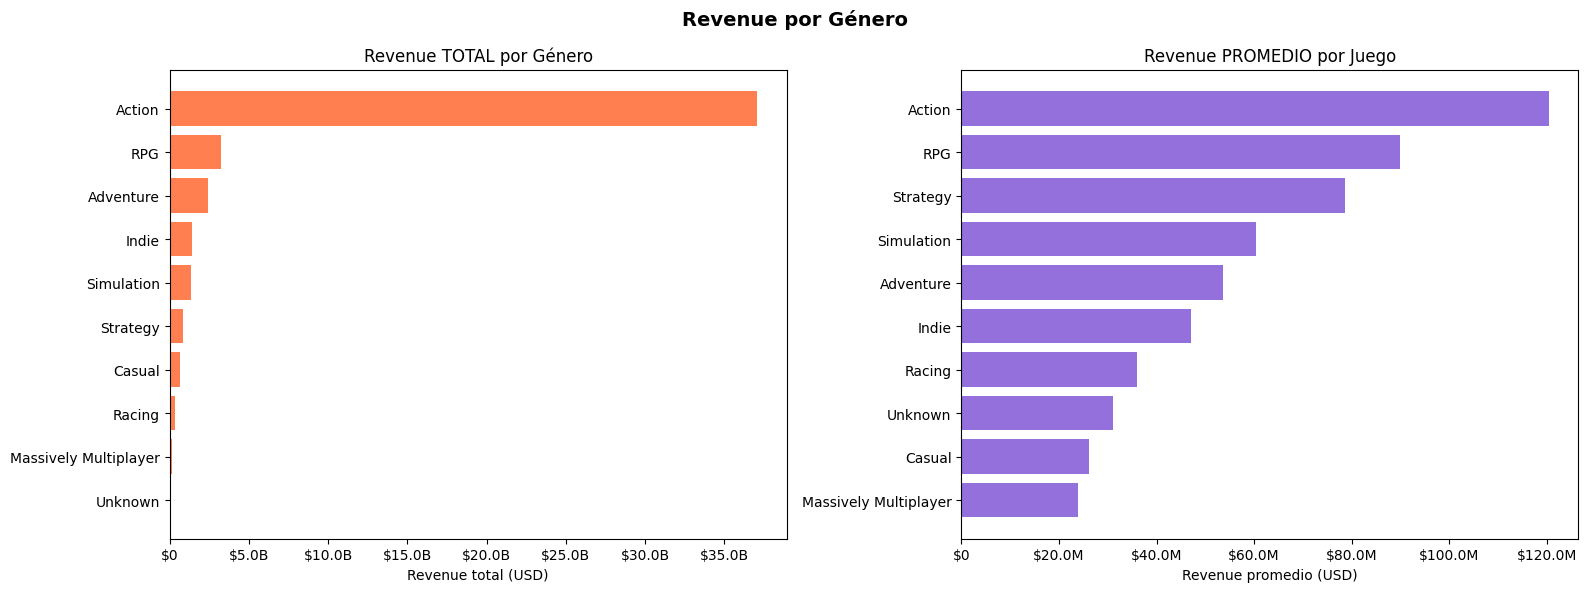

Género con mayor revenue total:   Action
Género con mayor revenue promedio: Action


In [ ]:
# ============================================================
# BLOQUE 3 — ANÁLISIS DE REVENUE POR GÉNERO
# ============================================================
# Por qué está acá: el revenue es el indicador económico central.
# Saber qué géneros generan más ingresos le dice a una empresa
# dónde conviene invertir.
#
# Preguntas que responde:
#   - ¿Qué género genera más revenue total?
#   - ¿Qué género tiene mejor revenue promedio por juego?

revenue_total = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].sum().sort_values(ascending=False).head(10)
revenue_promedio = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue por Género', fontsize=14, fontweight='bold')

axes[0].barh(revenue_total.index[::-1], revenue_total.values[::-1], color='coral')
axes[0].set_title('Revenue TOTAL por Género')
axes[0].set_xlabel('Revenue total (USD)')
axes[0].xaxis.set_major_formatter(FuncFormatter(currency_formatter))

axes[1].barh(revenue_promedio.index[::-1], revenue_promedio.values[::-1], color='mediumpurple')
axes[1].set_title('Revenue PROMEDIO por Juego')
axes[1].set_xlabel('Revenue promedio (USD)')
axes[1].xaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.tight_layout()
plt.show()

mejor_total = revenue_total.index[0]
mejor_promedio = revenue_promedio.index[0]

# Pie Chart: Revenue by Primary_Genre
revenue_by_genre = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].sum().reset_index()

fig_pie = px.pie(
    revenue_by_genre,
    values='Revenue',
    names='Primary_Genre',
    title='Porcentaje de Revenue por Género Principal',
    labels={'Primary_Genre': 'Género Principal', 'Revenue': 'Ingresos'},
    hole=0.0 # Optional: creates a donut chart
    )
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.show()

print(f"Género con mayor revenue total:   {mejor_total}")
print(f"Género con mayor revenue promedio: {mejor_promedio}")

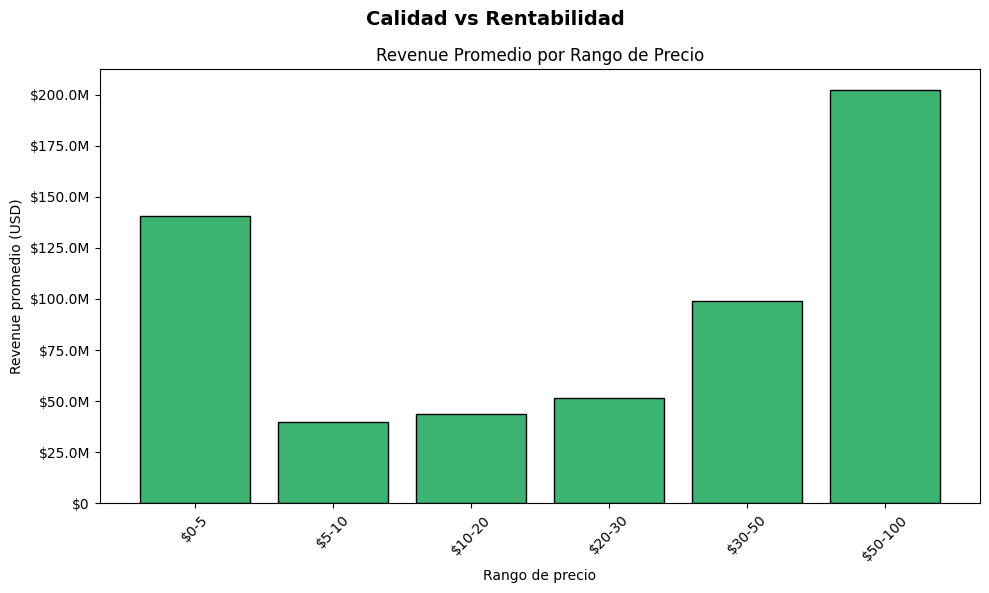

In [ ]:
# ============================================================
# BLOQUE 4 — CALIDAD VS RENTABILIDAD
# ============================================================
# Por qué está acá: una empresa no solo quiere vender mucho,
# quiere saber si vale la pena invertir en calidad. Este bloque
# analiza si los juegos mejor valorados generan más ingresos.
#
# Preguntas que responde:
#   - ¿Los juegos con mejores reviews generan más revenue?
#   - ¿Hay géneros con alta calidad pero bajo revenue (oportunidad)?
#   - ¿Cuál es el "punto dulce" de precio con mejor retorno?

fig, ax = plt.subplots(figsize=(10, 6)) # Changed to single subplot
fig.suptitle('Calidad vs Rentabilidad', fontsize=14, fontweight='bold')

# Scatter Plot: Review Score vs Revenue by Genre
fig_scatter_interactive = px.scatter(
    juegos_con_revenue,
    x='Review_Score_Pct_SteamDB',
    y='Revenue',
    color='Primary_Genre',
    title='Review Score vs Revenue por Género (Interactivo)',
    labels={
        'Review_Score_Pct_SteamDB': 'Review Score (%)',
        'Revenue': 'Revenue (USD)'
    },
    hover_name='Name', # Show game name on hover
    hover_data={'Primary_Genre': True, 'Price_USD': True, 'Total_Reviews': True} # Additional data on hover
)

# Apply currency formatting to the y-axis (Revenue)
fig_scatter_interactive.update_yaxes(tickprefix='$', tickformat=",.0f") # Format as currency with no decimal places

fig_scatter_interactive.show()

# Revenue promedio por rango de precio
bins = [0, 5, 10, 20, 30, 50, 100, 1000]
labels = ['$0-5', '$5-10', '$10-20', '$20-30', '$30-50', '$50-100', '$100+']
juegos_con_revenue['Rango_Precio'] = pd.cut(juegos_con_revenue['Price_USD'], bins=bins, labels=labels, right=False)
revenue_por_rango = juegos_con_revenue.groupby('Rango_Precio', observed=True)['Revenue'].mean()

ax.bar(revenue_por_rango.index, revenue_por_rango.values, color='mediumseagreen', edgecolor='black')
ax.set_title('Revenue Promedio por Rango de Precio')
ax.set_xlabel('Rango de precio')
ax.set_ylabel('Revenue promedio (USD)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.tight_layout()
plt.show()

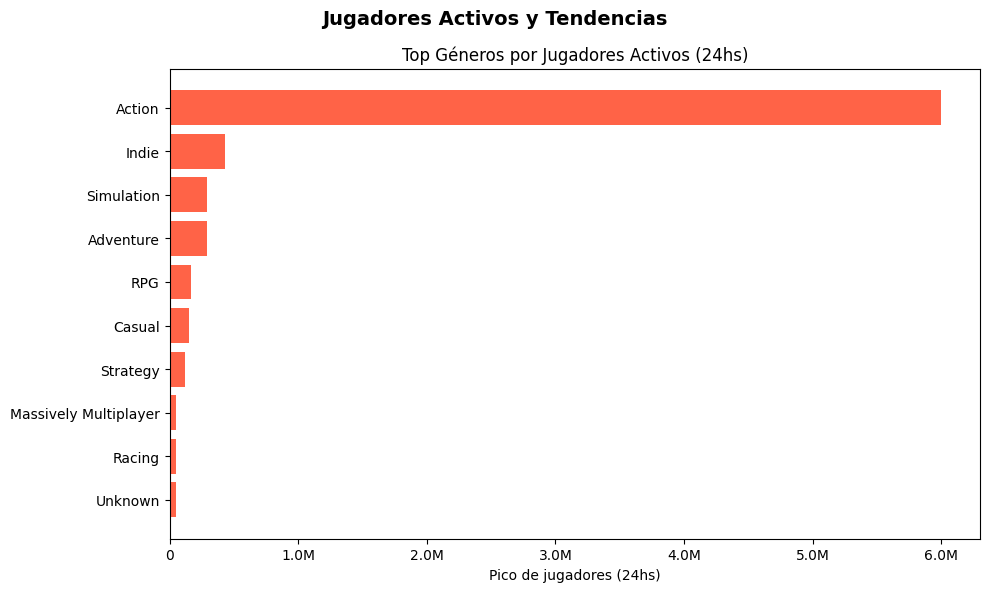

In [ ]:
# ============================================================
# BLOQUE 5 — JUGADORES ACTIVOS Y TENDENCIAS
# ============================================================
# Por qué está acá: el revenue mira el pasado, los jugadores
# activos miran el presente. Este bloque identifica qué géneros
# tienen comunidades vivas hoy, lo cual es clave para una
# empresa que quiere lanzar un juego nuevo.
#
# Pregunta que responde:
#   - ¿Qué géneros tienen más jugadores activos ahora?

fig, ax = plt.subplots(figsize=(10, 6)) # Changed to single subplot and adjusted figure size
fig.suptitle('Jugadores Activos y Tendencias', fontsize=14, fontweight='bold')

# Top géneros por pico de jugadores activos
jugadores_por_genero = df.groupby('Primary_Genre')['24h_Peak_Players'].sum().sort_values(ascending=False).head(10)
ax.barh(jugadores_por_genero.index[::-1], jugadores_por_genero.values[::-1], color='tomato')
ax.set_title('Top Géneros por Jugadores Activos (24hs)')
ax.set_xlabel('Pico de jugadores (24hs)')
ax.xaxis.set_major_formatter(FuncFormatter(player_formatter))

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOQUE 6 — CONCLUSIONES Y RECOMENDACIONES
# ============================================================
# Por qué está acá: este es el producto final de la consultora.
# No alcanza con mostrar datos, hay que traducirlos en decisiones
# concretas para el cliente.
#
# Preguntas que responde:
#   - ¿En qué género debería invertir una empresa nueva?
#   - ¿A qué precio debería lanzar su juego?

mejor_genero_revenue = revenue_total.index[0]
mejor_genero_jugadores = jugadores_por_genero.index[0]
precio_optimo = revenue_por_rango.idxmax()

print("=" * 55)
print("   RECOMENDACIONES — STEAM GAMES CONSULTORA")
print("=" * 55)

print(f"""
GÉNERO RECOMENDADO PARA INVERSIÓN:
  → Por revenue total:      {mejor_genero_revenue}
  → Por jugadores activos:  {mejor_genero_jugadores}

ESTRATEGIA DE PRECIO SUGERIDA:
  → El rango con mejor revenue promedio es: {precio_optimo}

CONCLUSIÓN GENERAL:
  Una empresa que quiera entrar al mercado de Steam
  debería apuntar a géneros con alta demanda activa
  y revenue sostenido, con un precio en el rango óptimo
  identificado.
""")

   RECOMENDACIONES — STEAM GAMES CONSULTORA

GÉNERO RECOMENDADO PARA INVERSIÓN:
  → Por revenue total:      Action
  → Por jugadores activos:  Action

ESTRATEGIA DE PRECIO SUGERIDA:
  → El rango con mejor revenue promedio es: $50-100

CONCLUSIÓN GENERAL:
  Una empresa que quiera entrar al mercado de Steam
  debería apuntar a géneros con alta demanda activa
  y revenue sostenido, con un precio en el rango óptimo
  identificado.



In [ ]:
from google.colab import files
uploaded = files.upload()
df2 = pd.read_csv("games_dataset.csv", encoding='latin1', sep=',', decimal=',')

Saving games_dataset.csv to games_dataset (1).csv


In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

df3 = pd.read_csv('steamdb_game_releases_per_year.csv', encoding='UTF-8-SIG', sep=';')

Saving steamdb_game_releases_per_year.csv to steamdb_game_releases_per_year.csv


TOP 10 — SCORING 4: Accesibilidad Multiplataforma
                           title  win  mac  linux  steam_deck  positive_ratio  S4_Accesibilidad
                        Terraria True True   True        True              97             0.949
Counter-Strike: Global Offensive True True   True        True              88             0.943
                  Stardew Valley True True   True        True              98             0.942
                     Garry's Mod True True   True        True              96             0.942
                   Left 4 Dead 2 True True   True        True              97             0.940
          Euro Truck Simulator 2 True True   True        True              97             0.937
                        Portal 2 True True   True        True              98             0.933
                 Team Fortress 2 True True   True        True              93             0.930
                   Hollow Knight True True   True        True              97         

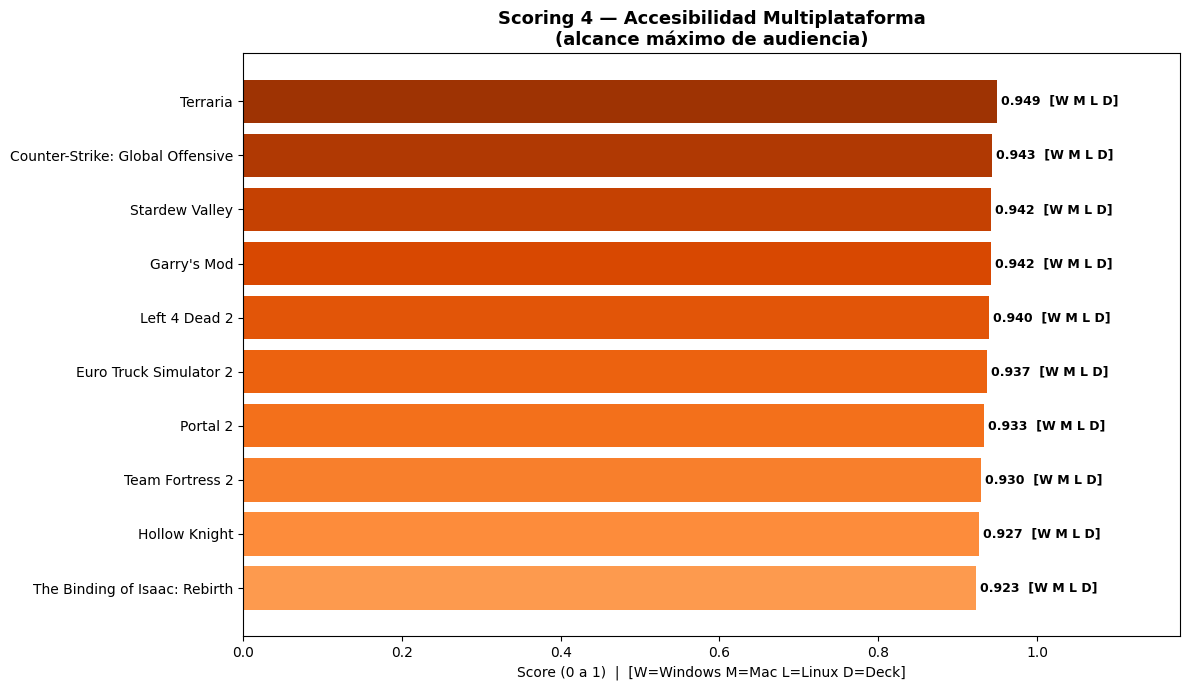

In [ ]:
# ============================================================
# SCORING 4 — ACCESIBILIDAD MULTIPLATAFORMA
# ============================================================
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

df2 = pd.read_csv("games_dataset.csv", encoding='latin1', sep=',', decimal=',')
df_s4 = df2[df2['user_reviews'] >= 100].copy()

scaler4 = MinMaxScaler()

# Cobertura de plataformas: suma de todas las plataformas disponibles
df_s4['plataformas'] = (
    df_s4['win'].astype(int) +
    df_s4['mac'].astype(int) +
    df_s4['linux'].astype(int) +
    df_s4['steam_deck'].astype(int)
)
df_s4['plataformas_n'] = scaler4.fit_transform(df_s4[['plataformas']])
df_s4['positive_n']    = scaler4.fit_transform(df_s4[['positive_ratio']])
df_s4['log_reviews']   = np.log1p(df_s4['user_reviews'])
df_s4['log_reviews_n'] = scaler4.fit_transform(df_s4[['log_reviews']])

df_s4['S4_Accesibilidad'] = (
    df_s4['positive_n']    * 0.45 +
    df_s4['plataformas_n'] * 0.35 +
    df_s4['log_reviews_n'] * 0.20
).round(3)

top10_s4 = df_s4.nlargest(10, 'S4_Accesibilidad')[
    ['title', 'win', 'mac', 'linux', 'steam_deck', 'positive_ratio', 'S4_Accesibilidad']
]

print("TOP 10 — SCORING 4: Accesibilidad Multiplataforma")
print(top10_s4.to_string(index=False))

# Gráfico con íconos de plataformas en anotación
fig, ax = plt.subplots(figsize=(12, 7))
colores4 = plt.cm.Oranges(np.linspace(0.45, 0.9, 10))
bars4 = ax.barh(top10_s4['title'][::-1], top10_s4['S4_Accesibilidad'][::-1], color=colores4)

for bar, val, w, m, l, sd in zip(bars4,
                                   top10_s4['S4_Accesibilidad'][::-1],
                                   top10_s4['win'][::-1],
                                   top10_s4['mac'][::-1],
                                   top10_s4['linux'][::-1],
                                   top10_s4['steam_deck'][::-1]):
    plats = f"{'W' if w else '·'} {'M' if m else '·'} {'L' if l else '·'} {'D' if sd else '·'}"
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}  [{plats}]', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, 1.18)
ax.set_xlabel('Score (0 a 1)  |  [W=Windows M=Mac L=Linux D=Deck]', fontsize=10)
ax.set_title('Scoring 4 — Accesibilidad Multiplataforma\n(alcance máximo de audiencia)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== DISPONIBILIDAD POR SISTEMA OPERATIVO ===
Windows   : 50,076 juegos (98.4%)
Mac       : 13,018 juegos (25.6%)
Linux     : 9,041 juegos (17.8%)


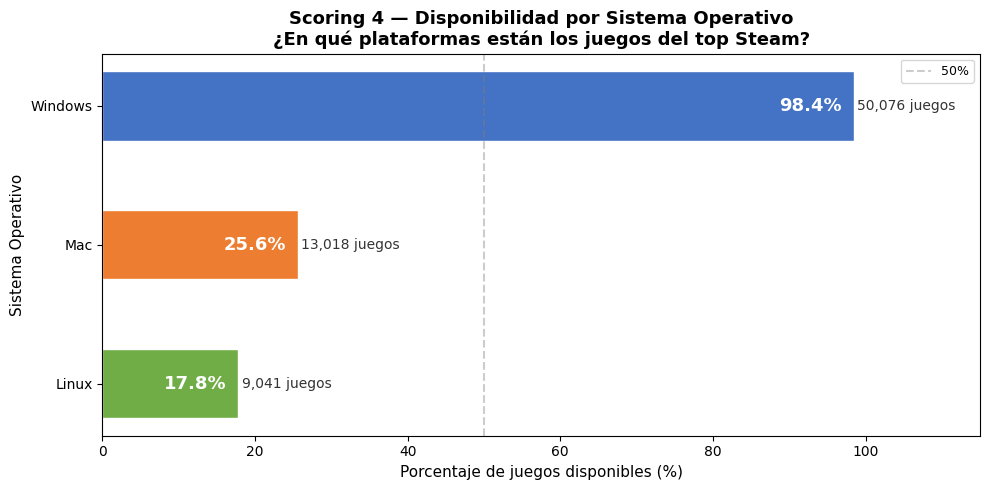

In [ ]:
# ============================================================
# SCORING 4 — DISPONIBILIDAD POR SISTEMA OPERATIVO
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

total = len(df2)

# Solo sistemas operativos de PC (Steam Deck excluido)
plataformas = {
    'Windows': int(df2['win'].sum()),
    'Mac':     int(df2['mac'].sum()),
    'Linux':   int(df2['linux'].sum())
}

labels   = list(plataformas.keys())
valores  = list(plataformas.values())
porcentajes = [v / total * 100 for v in valores]
colores  = ['#4472C4', '#ED7D31', '#70AD47']

print("=== DISPONIBILIDAD POR SISTEMA OPERATIVO ===")
for plat, cantidad, pct in zip(labels, valores, porcentajes):
    print(f"{plat:10}: {cantidad:,} juegos ({pct:.1f}%)")

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(labels[::-1], porcentajes[::-1],
               color=colores[::-1], edgecolor='white', height=0.5)

# Etiqueta con porcentaje Y cantidad exacta dentro/fuera de cada barra
for bar, pct, cant in zip(bars, porcentajes[::-1], valores[::-1]):
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', ha='right',
            fontsize=13, fontweight='bold', color='white')
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{cant:,} juegos', va='center', ha='left',
            fontsize=10, color='#333333')

ax.set_xlim(0, 115)
ax.set_xlabel('Porcentaje de juegos disponibles (%)', fontsize=11)
ax.set_ylabel('Sistema Operativo', fontsize=11)
ax.set_title('Scoring 4 — Disponibilidad por Sistema Operativo\n'
             '¿En qué plataformas están los juegos del top Steam?',
             fontsize=13, fontweight='bold')

# Línea de referencia al 50%
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.4, label='50%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('scoring4_so.png', dpi=150, bbox_inches='tight')
plt.show()

Juegos en el merge: 282

Comparación de fuentes de calidad:
                                  Name  Review_Score_Pct_SteamDB  positive_ratio                   rating
0                     Counter-Strike 2                     85.88              88            Very Positive
1                         Ready or Not                     77.21              91            Very Positive
2                        Apex Legends                     67.35              80            Very Positive
3                             Teardown                     94.29              96  Overwhelmingly Positive
4                          The Sims 4                     85.63              87            Very Positive
5       Tom Clancy's Rainbow Six Siege                     82.02              86            Very Positive
6                             Warframe                     86.68              86            Very Positive
7                           Overwatch®                     30.25               9  Overwhelmi

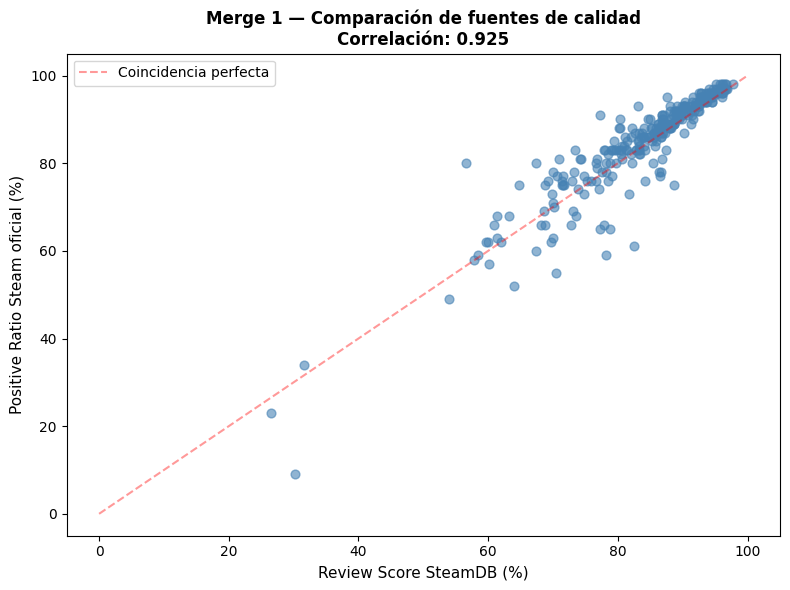

In [ ]:
# ============================================================
# MERGE 1 — ENRIQUECIMIENTO DE CALIDAD
# Unir Review_Score_SteamDB con positive_ratio oficial de Steam
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv("steam_games_500_2026.csv", sep=';', encoding='latin-1', decimal=',')
df2 = pd.read_csv("games_dataset.csv", encoding='utf-8')

df1['AppID']   = pd.to_numeric(df1['AppID'], errors='coerce')
df2['app_id']  = pd.to_numeric(df2['app_id'], errors='coerce')
df2['positive_ratio'] = pd.to_numeric(df2['positive_ratio'], errors='coerce')

# Merge por AppID — inner: solo juegos presentes en ambos
merge1 = pd.merge(
    df1[['AppID', 'Name', 'Primary_Genre', 'Review_Score_Pct_SteamDB',
         'Revenue' if 'Revenue' in df1.columns else 'Estimated_Owners']],
    df2[['app_id', 'positive_ratio', 'rating']],
    left_on='AppID', right_on='app_id',
    how='inner'
)

print(f"Juegos en el merge: {len(merge1)}")
print(f"\nComparación de fuentes de calidad:")
print(merge1[['Name', 'Review_Score_Pct_SteamDB', 'positive_ratio', 'rating']].head(10).to_string())

# Correlación entre las dos fuentes
correlacion = merge1['Review_Score_Pct_SteamDB'].corr(merge1['positive_ratio'])
print(f"\nCorrelación entre SteamDB score y positive_ratio: {correlacion:.3f}")

# Scatter para ver la relación
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merge1['Review_Score_Pct_SteamDB'], merge1['positive_ratio'],
           alpha=0.6, color='steelblue', s=40)
ax.set_xlabel('Review Score SteamDB (%)', fontsize=11)
ax.set_ylabel('Positive Ratio Steam oficial (%)', fontsize=11)
ax.set_title('Merge 1 — Comparación de fuentes de calidad\n'
             f'Correlación: {correlacion:.3f}', fontsize=12, fontweight='bold')

# Línea de referencia perfecta (si coincidieran 100%)
ax.plot([0, 100], [0, 100], 'r--', alpha=0.4, label='Coincidencia perfecta')
ax.legend()
plt.tight_layout()
plt.show()

=== FORECAST — JUEGOS NUEVOS EN STEAM ===
  2023: ~8,009 juegos estimados
  2024: ~8,602 juegos estimados
  2025: ~9,187 juegos estimados


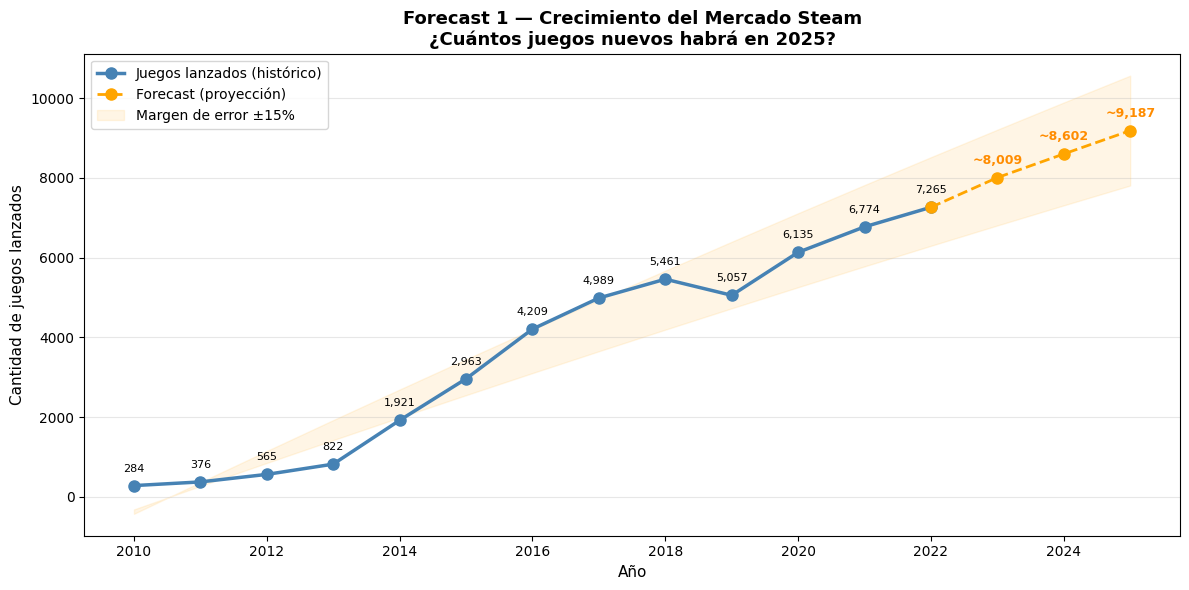

In [ ]:
# ============================================================
# FORECAST 1 — CRECIMIENTO DEL MERCADO STEAM POR AÑO
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

df2 = pd.read_csv("games_dataset.csv", encoding='utf-8')
df2['year'] = pd.to_datetime(df2['date_release'], errors='coerce').dt.year

# Serie histórica: juegos lanzados por año (2010-2022)
# Excluimos 2023 porque está incompleto en el dataset
serie = (df2[df2['year'].between(2010, 2022)]
         .groupby('year').size().reset_index(name='juegos'))

X = serie['year'].values.reshape(-1, 1)
y = serie['juegos'].values

# Modelo polinomial grado 2 (capta la aceleración del crecimiento)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
modelo = LinearRegression()
modelo.fit(X_poly, y)

# Predicción 2023, 2024, 2025
años_forecast = np.array([2023, 2024, 2025]).reshape(-1, 1)
X_forecast = poly.transform(años_forecast)
predicciones = modelo.predict(X_forecast).astype(int)

print("=== FORECAST — JUEGOS NUEVOS EN STEAM ===")
for año, pred in zip([2023, 2024, 2025], predicciones):
    print(f"  {año}: ~{pred:,} juegos estimados")

# Gráfico
años_hist = serie['year'].values
años_todos = np.arange(2010, 2026).reshape(-1, 1)
pred_todos = modelo.predict(poly.transform(años_todos))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(años_hist, y, 'o-', color='steelblue', linewidth=2.5,
        markersize=8, label='Juegos lanzados (histórico)', zorder=5)
ax.plot([2022, 2023, 2024, 2025],
        [y[-1]] + list(predicciones),
        'o--', color='orange', linewidth=2, markersize=8,
        label='Forecast (proyección)', zorder=5)

# Anotaciones
for año, val in zip(años_hist, y):
    ax.annotate(f'{val:,}', (año, val), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8)
for año, pred in zip([2023, 2024, 2025], predicciones):
    ax.annotate(f'~{pred:,}', (año, pred), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9,
                color='darkorange', fontweight='bold')

ax.fill_between(años_todos.flatten(), pred_todos * 0.85, pred_todos * 1.15,
                alpha=0.1, color='orange', label='Margen de error ±15%')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Cantidad de juegos lanzados', fontsize=11)
ax.set_title('Forecast 1 — Crecimiento del Mercado Steam\n'
             '¿Cuántos juegos nuevos habrá en 2025?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

=== FORECAST — REVENUE POR AÑO ===
  2015: $3.25B (histórico)
  2016: $4.83B (histórico)
  2017: $3.01B (histórico)
  2018: $4.25B (histórico)
  2019: $3.79B (histórico)
  2020: $6.47B (histórico)
  2021: $2.76B (histórico)
  2022: $4.66B (histórico)
  2023: $5.80B (histórico)
  2024: $8.24B (histórico)
  2025: ~$6.65B (forecast)
  2026: ~$7.00B (forecast)


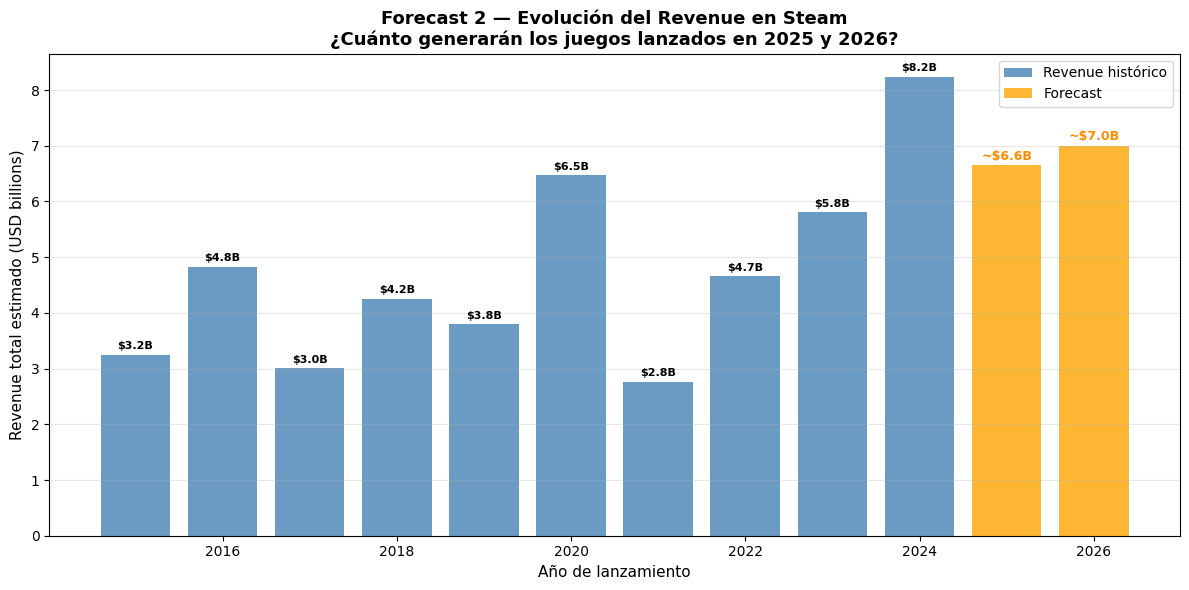

In [ ]:
# ============================================================
# FORECAST 2 — EVOLUCIÓN DEL REVENUE POR AÑO DE LANZAMIENTO
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df1 = pd.read_csv("steam_games_500_2026.csv", sep=';', encoding='latin-1', decimal=',')

# Calcular Revenue
ARPU_base = {"Action":13,"Adventure":9,"RPG":20,"Strategy":13,
             "Simulation":8,"Casual":6,"Massively Multiplayer":22,
             "Indie":7,"Sports":11,"Racing":9}
df1['ARPU'] = df1['Primary_Genre'].map(ARPU_base).fillna(10)
df1 = df1[df1['Total_Reviews'] > 0].copy()
df1['Revenue'] = df1['Estimated_Owners'] * df1['Price_USD']
free = df1['Price_USD'] == 0
df1.loc[free, 'Revenue'] = df1.loc[free, 'Estimated_Owners'] * df1.loc[free, 'ARPU']

df1['year'] = pd.to_datetime(df1['Release_Date'], dayfirst=True, errors='coerce').dt.year

# Serie: revenue total por año de lanzamiento (2015-2024)
serie = (df1[df1['year'].between(2015, 2024)]
         .groupby('year')['Revenue'].sum().reset_index())

X = serie['year'].values.reshape(-1, 1)
y = serie['Revenue'].values

modelo = LinearRegression()
modelo.fit(X, y)

pred_2025 = modelo.predict([[2025]])[0]
pred_2026 = modelo.predict([[2026]])[0]

print("=== FORECAST — REVENUE POR AÑO ===")
for año, val in zip(serie['year'], y):
    print(f"  {año}: ${val/1e9:.2f}B (histórico)")
print(f"  2025: ~${pred_2025/1e9:.2f}B (forecast)")
print(f"  2026: ~${pred_2026/1e9:.2f}B (forecast)")

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(serie['year'], serie['Revenue'] / 1e9,
       color='steelblue', alpha=0.8, label='Revenue histórico')
ax.bar([2025, 2026], [pred_2025/1e9, pred_2026/1e9],
       color='orange', alpha=0.8, label='Forecast')

for año, val in zip(serie['year'], serie['Revenue']):
    ax.text(año, val/1e9 + 0.1, f'${val/1e9:.1f}B',
            ha='center', fontsize=8, fontweight='bold')
for año, val in zip([2025, 2026], [pred_2025, pred_2026]):
    ax.text(año, val/1e9 + 0.1, f'~${val/1e9:.1f}B',
            ha='center', fontsize=9, fontweight='bold', color='darkorange')

ax.set_xlabel('Año de lanzamiento', fontsize=11)
ax.set_ylabel('Revenue total estimado (USD billions)', fontsize=11)
ax.set_title('Forecast 2 — Evolución del Revenue en Steam\n'
             '¿Cuánto generarán los juegos lanzados en 2025 y 2026?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Please upload steam_games_500_2026.csv and games_dataset.csv


Saving steam_games_500_2026.csv to steam_games_500_2026.csv
=== VARIACIÓN DE PRECIO POR GÉNERO ===
Primary_Genre  precio_top500  precio_actual  variacion_media  juegos
    Adventure      35.990000      35.990000         0.000000       5
          RPG      25.802500      25.802500         0.000000      16
       Action      21.517778      20.934444        -1.158333      36
     Strategy      28.740000       9.990000       -53.550000       4


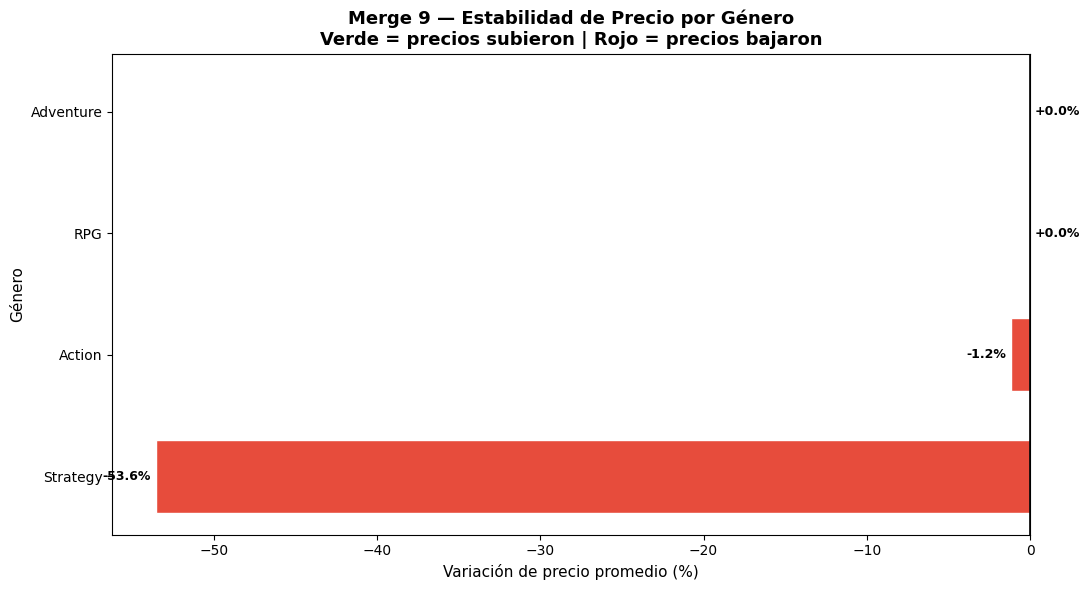

In [ ]:
# ============================================================
# MERGE 9 — ÍNDICE DE PRECIO JUSTO POR GÉNERO
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print('Please upload steam_games_500_2026.csv and games_dataset.csv')
uploaded_files = files.upload()

df1 = pd.read_csv('steam_games_500_2026.csv', sep=';', encoding='latin-1', decimal=',')
df2 = pd.read_csv('games_dataset.csv', encoding='utf-8')

df1['AppID']        = pd.to_numeric(df1['AppID'], errors='coerce')
df2['app_id']       = pd.to_numeric(df2['app_id'], errors='coerce')
df2['price_final']  = pd.to_numeric(df2['price_final'], errors='coerce')
df2['price_original'] = pd.to_numeric(df2['price_original'], errors='coerce')

merge9 = pd.merge(
    df1[['AppID', 'Name', 'Primary_Genre', 'Price_USD']],
    df2[['app_id', 'price_final', 'price_original']],
    left_on='AppID', right_on='app_id', how='inner'
)

# Solo juegos de pago en ambas fuentes
merge9 = merge9[(merge9['Price_USD'] > 0) & (merge9['price_original'] > 0)].copy()

# Variación de precio: price_original del dataset grande vs Price_USD del principal
merge9['variacion_pct'] = ((merge9['price_original'] - merge9['Price_USD']) /
                            merge9['Price_USD'] * 100).round(1)

# Promedio por género
precio_genero = (merge9.groupby('Primary_Genre')
                 .agg(precio_top500=('Price_USD', 'mean'),
                      precio_actual=('price_original', 'mean'),
                      variacion_media=('variacion_pct', 'mean'),
                      juegos=('Name', 'count'))
                 .reset_index()
                 .sort_values('variacion_media', ascending=False))
precio_genero = precio_genero[precio_genero['juegos'] >= 3]

print("=== VARIACIÓN DE PRECIO POR GÉNERO ===")
print(precio_genero.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colores = ['#2ecc71' if v >= 0 else '#e74c3c'
           for v in precio_genero['variacion_media'][::-1]]
bars = ax.barh(precio_genero['Primary_Genre'][::-1],
               precio_genero['variacion_media'][::-1],
               color=colores, edgecolor='white', height=0.6)

ax.axvline(x=0, color='black', linewidth=1.2)
for bar, val in zip(bars, precio_genero['variacion_media'][::-1]):
    offset = 0.3 if val >= 0 else -0.3
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_xlabel('Variación de precio promedio (%)', fontsize=11)
ax.set_ylabel('Género', fontsize=11)
ax.set_title('Merge 9 — Estabilidad de Precio por Género\n'
             'Verde = precios subieron | Rojo = precios bajaron',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Cargar el dataset especificando que el separador es punto y coma ';'
df = pd.read_csv('steamdb_game_releases_per_year.csv', sep=';')

# 2. Limpieza y procesamiento de fechas
# Quitamos las comillas si las hubiera y convertimos a formato fecha
df['DateTime'] = df['DateTime'].astype(str).str.replace('"', '')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Year'] = df['DateTime'].dt.year

# Ordenamos por año para que la línea de tiempo sea correcta
df = df.sort_values('Year')

# 3. CREACIÓN DEL GRÁFICO PROFESIONAL (Barras Apiladas)
fig = go.Figure()

# Barra 1: Juegos Estándar (Games)
fig.add_trace(go.Bar(
    x=df['Year'],
    y=df['Games'],
    name='Juegos Estándar',
    marker_color='#1f77b4',  # Azul corporativo
    opacity=0.85
))

# Barra 2: Juegos Limitados (Limited Games)
fig.add_trace(go.Bar(
    x=df['Year'],
    y=df['Limited Games'],
    name='Juegos Limitados (Steam Profile Features Limited)',
    marker_color='#aec7e8',  # Azul claro para contraste
    opacity=0.85
))

# 4. Diseño de Alta Gama (Estilo Dashboard Ejecutivo)
fig.update_layout(
    title={
        'text': "<b>Evolución Histórica de Lanzamientos en Steam</b><br><span style='font-size:13px; color:gray;'>Volumen total anual incluyendo la segmentación de juegos con perfil limitado</span>",
        'y': 0.94, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis=dict(
        title="Año de Lanzamiento",
        tickmode='linear',
        dtick=2,  # Muestra los años de 2 en 2 para que no se amontone
        gridcolor='rgba(200, 200, 200, 0.15)',
        tickangle=-45
    ),
    yaxis=dict(
        title="Cantidad de Videojuegos Lanzados",
        gridcolor='rgba(200, 200, 200, 0.15)',
        titlefont=dict(size=14)
    ),
    barmode='stack',  # Apila las barras para ver el VOLUMEN TOTAL REAL en el gráfico
    template='plotly_white',
    hovermode='x unified',  # Al pasar el mouse, te muestra el total y el desglose del año
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(l=60, r=40, t=120, b=60)
)

# 5. Mostrar el gráfico en el navegador o Jupyter Notebook
fig.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import plotly.graph_objects as go

# 1. CARGA, LIMPIEZA Y PROCESAMIENTO DE DATOS
# ==========================================
df = pd.read_csv('steamdb_game_releases_per_year.csv', sep=';')
df['DateTime'] = df['DateTime'].astype(str).str.replace('"', '')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Year'] = df['DateTime'].dt.year

# Aseguramos el orden cronológico
df = df.sort_values('Year')

# Separamos los datos históricos reales (hasta 2023)
df_historic = df[(df['Year'] >= 2010) & (df['Year'] <= 2023)].copy()

# ==========================================
# 2. ENTRENAMIENTO DEL MODELO DE FORECAST
# ==========================================
# Entrenamos con el volumen total (Games + Limited Games) para no perder el 50% del mercado
X_train = df_historic['Year'].values.reshape(-1, 1)
y_games_train = df_historic['Games'].values
y_limited_train = df_historic['Limited Games'].values

# Usamos regresión polinomial para acompañar la curva de crecimiento exponencial de Steam
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)

# Entrenamos un modelo para cada tipo de juego para mantener la segmentación en el futuro
model_games = LinearRegression().fit(X_poly_train, y_games_train)
model_limited = LinearRegression().fit(X_poly_train, y_limited_train)

# Proyectamos los años del Forecast (2024, 2025 y 2026)
years_future = np.array([2024, 2025, 2026]).reshape(-1, 1)
X_poly_future = poly.transform(years_future)

pred_games = np.clip(model_games.predict(X_poly_future), 0, None)  # Evita números negativos
pred_limited = np.clip(model_limited.predict(X_poly_future), 0, None)

# Crear DataFrame con las predicciones para acoplarlas al gráfico
df_future = pd.DataFrame({
    'Year': years_future.flatten(),
    'Games': pred_games,
    'Limited Games': pred_limited
})

# ==========================================
# 3. CONSTRUCCIÓN DEL GRÁFICO CON ESTÉTICA DE PRESTIGIO
# ==========================================
fig = go.Figure()

# --- DATOS HISTÓRICOS REALES (Barras Sólidas) ---
fig.add_trace(go.Bar(
    x=df_historic['Year'],
    y=df_historic['Games'],
    name='Juegos Estándar (Histórico)',
    marker_color='#1f77b4',
    opacity=0.95
))

fig.add_trace(go.Bar(
    x=df_historic['Year'],
    y=df_historic['Limited Games'],
    name='Juegos Limitados (Histórico)',
    marker_color='#aec7e8',
    opacity=0.95
))

# --- DATOS DEL FORECAST (Barras con Tono Diferenciado / Líneas de Patrón) ---
fig.add_trace(go.Bar(
    x=df_future['Year'],
    y=df_future['Games'],
    name='Juegos Estándar (Forecast)',
    marker_color='#1a5f90',
    marker_pattern_shape="/",  # Textura sutil para indicar predicción en imprenta
    opacity=0.85
))

fig.add_trace(go.Bar(
    x=df_future['Year'],
    y=df_future['Limited Games'],
    name='Juegos Limitados (Forecast)',
    marker_color='#93b5de',
    marker_pattern_shape="/",
    opacity=0.85
))

# ==========================================
# 4. EFECTO VISUAL: LA SOMBRA DE FONDO (FORECAST ZONE)
# ==========================================
# Añade un rectángulo gris/azul sutil detrás de los años proyectados (2023.5 a 2026.5)
fig.add_vrect(
    x0=2023.5, x1=2026.5,
    fillcolor="rgba(220, 225, 235, 0.5)",
    layer="below",
    line_width=0,
    annotation=dict(
        text="<b>ZONA DE FORECAST PROYECTADO</b>",
        x=(2023.5 + 2026.5) / 2, # Center X coordinate for the annotation
        y=1, # Y coordinate (normalized, 1 is the top of the plot area)
        showarrow=False,
        xanchor="center",
        yanchor="top", # Anchor the top of the text to the y coordinate
        font=dict(size=11, color="#555555")
    )
)

# Linea vertical divisoria entre Realidad y Forecast
fig.add_vline(
    x=2023.5,
    line_width=1.5,
    line_dash="dash",
    line_color="#7f7f7f"
)

# ==========================================
# 5. MAQUETACIÓN Y ESTILO DEL TEMPLATE
# ==========================================
fig.update_layout(
    title={
        'text': "<b>Evolución del Mercado Steam & Forecast de Lanzamientos</b><br><span style='font-size:13px; color:gray;'>Análisis histórico (2010-2023) y proyección polinomial con separación estética de datos</span>",
        'y': 0.94, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis=dict(
        title="Año de Lanzamiento",
        tickmode='linear',
        dtick=1,  # Mostrar año por año para un control preciso de la línea de tiempo
        gridcolor='rgba(200, 200, 200, 0.15)',
        range=[2009.5, 2026.5]  # Encuadre perfecto en pantalla
    ),
    yaxis=dict(
        title="Cantidad de Videojuegos Lanzados",
        gridcolor='rgba(200, 200, 200, 0.15)'
    ),
    barmode='stack',  # Apiladas para ver el 100% real del volumen anual
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=60, r=40, t=130, b=60)
)

# Agregar etiquetas de texto con los valores exactos sobre las barras del Forecast
for idx, row in df_future.iterrows():
    total_pred = row['Games'] + row['Limited Games']
    fig.add_annotation(
        x=row['Year'], y=total_pred,
        text=f"<b>{int(total_pred):,}</b>",
        showarrow=False,
        yshift=8,
        font=dict(color="#111111", size=11)
    )

# Mostrar gráfico interactivo en pantalla
fig.show()


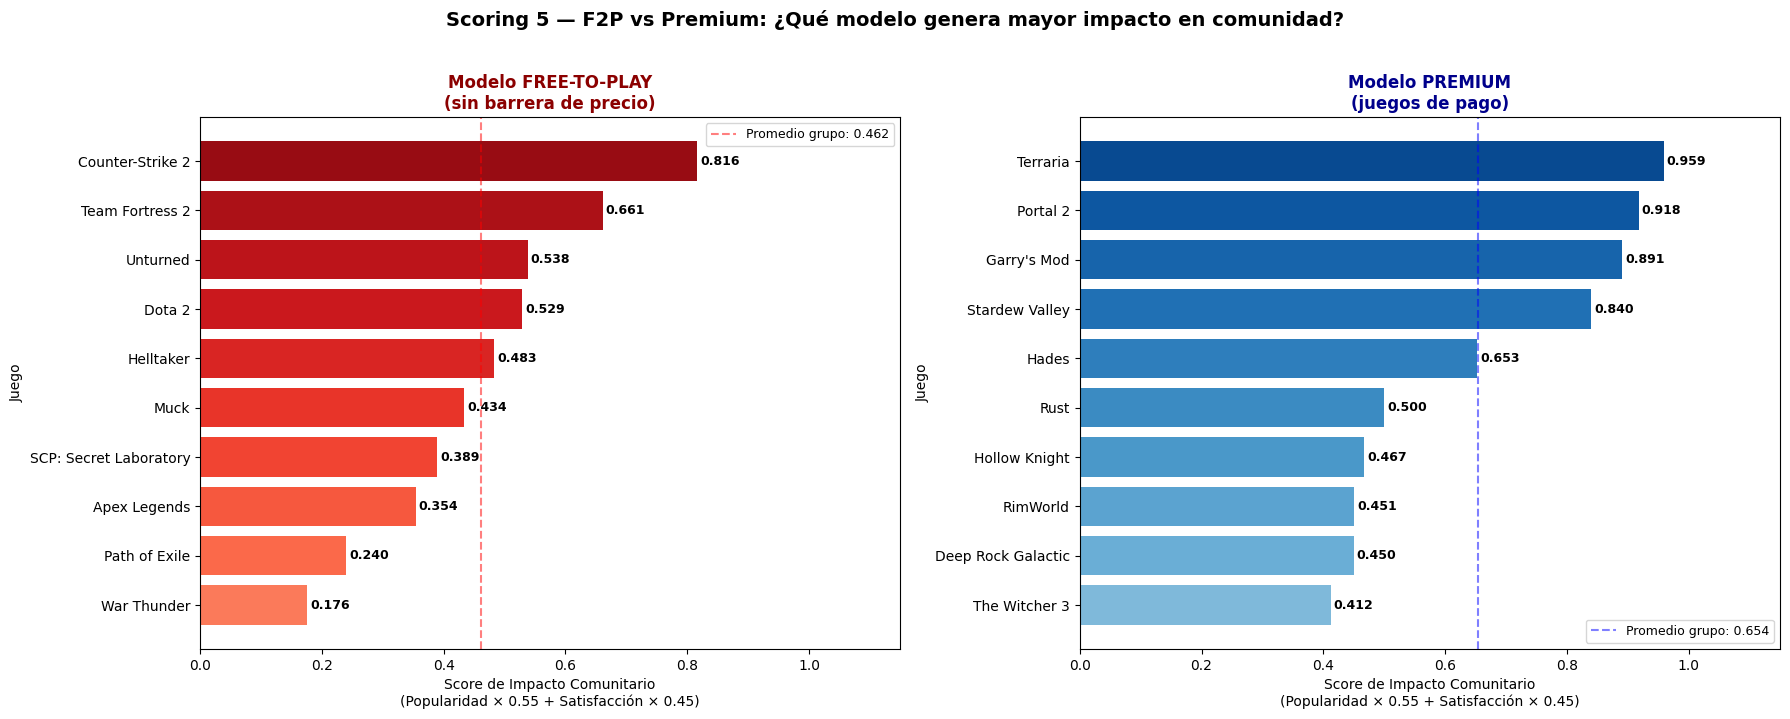


CONCLUSIÓN — SCORING 5: F2P vs PREMIUM
Score promedio F2P:     0.462
Score promedio Premium: 0.654
Modelo con mayor impacto comunitario: PREMIUM
Diferencia entre modelos: 0.192


In [ ]:
# ============================================================
# SCORING 5A y 5B — F2P vs PREMIUM: Comparativa de Impacto
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

data_f2p = {
    'title':          ['Counter-Strike 2', 'Dota 2', 'Team Fortress 2',
                       'Apex Legends', 'War Thunder', 'Path of Exile',
                       'Unturned', 'Helltaker', 'SCP: Secret Laboratory', 'Muck'],
    'user_reviews':   [7494460, 2045628, 985819, 713182, 393681,
                       152000, 515016, 127378, 98000, 139841],
    'positive_ratio': [88, 82, 93, 80, 75, 84, 91, 97, 94, 94],
}

data_premium = {
    'title':          ['Terraria', "Garry's Mod", 'Rust', 'Stardew Valley',
                       'Hollow Knight', 'Portal 2', 'RimWorld', 'Hades',
                       'Deep Rock Galactic', 'The Witcher 3'],
    'user_reviews':   [943413, 853733, 786668, 612000, 158000,
                       701000, 173000, 310000, 128000, 202000],
    'positive_ratio': [97, 96, 87, 97, 97, 98, 96, 97, 98, 94],
}

def calcular_scoring(df):
    scaler = MinMaxScaler()
    df = df.copy()
    df['log_reviews']   = np.log1p(df['user_reviews'])
    df['log_reviews_n'] = scaler.fit_transform(df[['log_reviews']])
    df['positive_n']    = scaler.fit_transform(df[['positive_ratio']])
    df['score'] = (
        df['log_reviews_n'] * 0.55 +
        df['positive_n']    * 0.45
    ).round(3)
    return df.sort_values('score', ascending=False)

df_f2p_scored     = calcular_scoring(pd.DataFrame(data_f2p))
df_premium_scored = calcular_scoring(pd.DataFrame(data_premium))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Scoring 5 — F2P vs Premium: ¿Qué modelo genera mayor impacto en comunidad?',
             fontsize=14, fontweight='bold', y=1.02)

# ── GRÁFICO A — F2P ──────────────────────────────────────
colores_f2p = plt.cm.Reds(np.linspace(0.45, 0.9, 10))
bars1 = ax1.barh(df_f2p_scored['title'][::-1],
                 df_f2p_scored['score'][::-1], color=colores_f2p)

# Solo el score encima de cada barra, sin el número de reviews
for bar, val in zip(bars1, df_f2p_scored['score'][::-1]):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax1.set_xlim(0, 1.15)
ax1.set_xlabel('Score de Impacto Comunitario\n(Popularidad × 0.55 + Satisfacción × 0.45)',
               fontsize=10)
ax1.set_ylabel('Juego', fontsize=10)
ax1.set_title('Modelo FREE-TO-PLAY\n(sin barrera de precio)',
              fontsize=12, fontweight='bold', color='darkred')
ax1.axvline(x=df_f2p_scored['score'].mean(), color='red',
            linestyle='--', alpha=0.5,
            label=f'Promedio grupo: {df_f2p_scored["score"].mean():.3f}')
ax1.legend(fontsize=9)

# ── GRÁFICO B — PREMIUM ──────────────────────────────────
colores_prem = plt.cm.Blues(np.linspace(0.45, 0.9, 10))
bars2 = ax2.barh(df_premium_scored['title'][::-1],
                 df_premium_scored['score'][::-1], color=colores_prem)

for bar, val in zip(bars2, df_premium_scored['score'][::-1]):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax2.set_xlim(0, 1.15)
ax2.set_xlabel('Score de Impacto Comunitario\n(Popularidad × 0.55 + Satisfacción × 0.45)',
               fontsize=10)
ax2.set_ylabel('Juego', fontsize=10)
ax2.set_title('Modelo PREMIUM\n(juegos de pago)',
              fontsize=12, fontweight='bold', color='darkblue')
ax2.axvline(x=df_premium_scored['score'].mean(), color='blue',
            linestyle='--', alpha=0.5,
            label=f'Promedio grupo: {df_premium_scored["score"].mean():.3f}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('scoring5_f2p_vs_premium.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CONCLUSIÓN AUTOMÁTICA ─────────────────────────────────
prom_f2p  = df_f2p_scored['score'].mean()
prom_prem = df_premium_scored['score'].mean()
ganador   = "FREE-TO-PLAY" if prom_f2p > prom_prem else "PREMIUM"
diferencia = abs(prom_f2p - prom_prem)

print("\n" + "="*55)
print("CONCLUSIÓN — SCORING 5: F2P vs PREMIUM")
print("="*55)
print(f"Score promedio F2P:     {prom_f2p:.3f}")
print(f"Score promedio Premium: {prom_prem:.3f}")
print(f"Modelo con mayor impacto comunitario: {ganador}")
print(f"Diferencia entre modelos: {diferencia:.3f}")

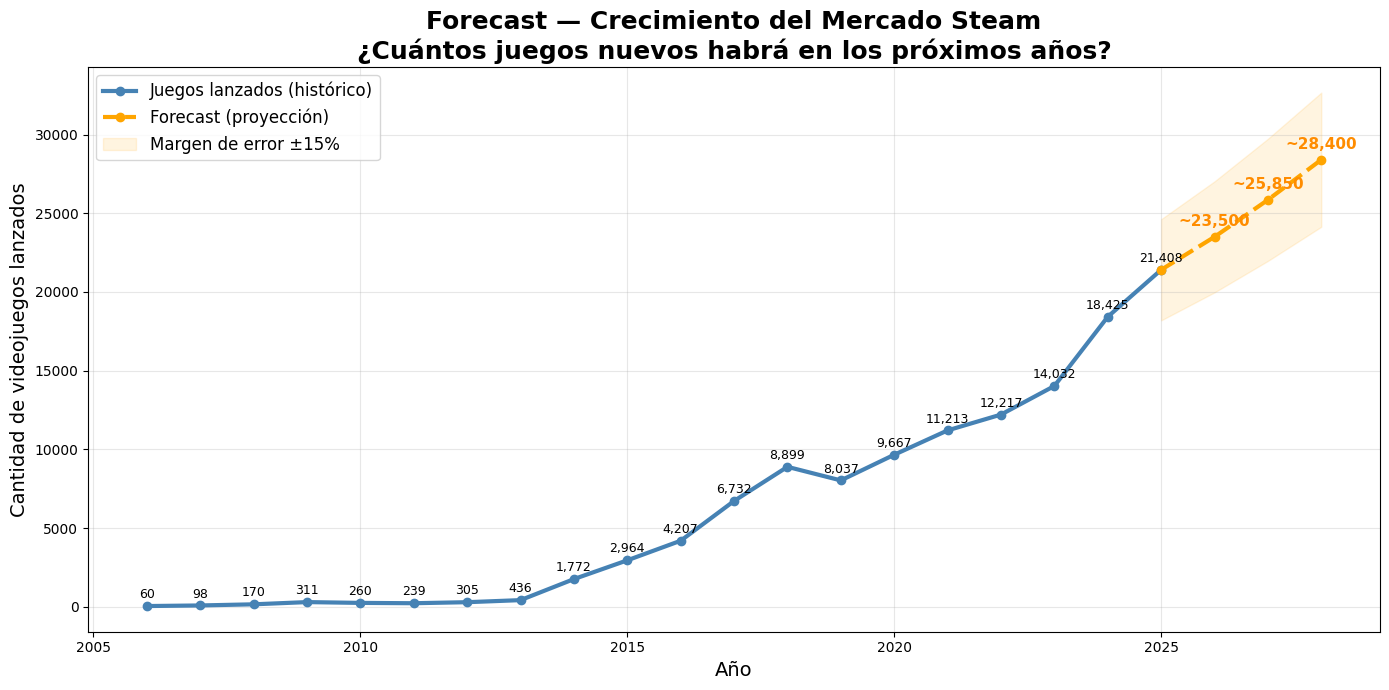

In [ ]:
# Crear un gráfico de líneas estilo forecast usando los datos históricos de Steam

import matplotlib.pyplot as plt
import numpy as np

# Datos históricos extraídos del gráfico
años = [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
        2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
        2022, 2023, 2024, 2025]

juegos = [60, 98, 170, 311, 260, 239, 305, 436,
          1772, 2964, 4207, 6732, 8899, 8037, 9667,
          11213, 12217, 14032, 18425, 21408]

# Proyección para 2026-2028
años_forecast = [2025, 2026, 2027, 2028]
forecast = [21408, 23500, 25850, 28400]

# Margen de error ±15%
error = np.array(forecast) * 0.15
lower = np.array(forecast) - error
upper = np.array(forecast) + error

plt.figure(figsize=(14,7))

# Serie histórica
plt.plot(
    años,
    juegos,
    marker='o',
    linewidth=3,
    color='steelblue',
    label='Juegos lanzados (histórico)'
)

# Forecast
plt.plot(
    años_forecast,
    forecast,
    marker='o',
    linestyle='--',
    linewidth=3,
    color='orange',
    label='Forecast (proyección)'
)

# Banda de confianza
plt.fill_between(
    años_forecast,
    lower,
    upper,
    color='orange',
    alpha=0.12,
    label='Margen de error ±15%'
)

# Etiquetas históricas
for x, y in zip(años, juegos):
    plt.text(x, y + 500, f'{y:,}', ha='center', fontsize=9)

# Etiquetas forecast
for x, y in zip(años_forecast[1:], forecast[1:]):
    plt.text(x, y + 700, f'~{y:,}', ha='center',
             fontsize=11, color='darkorange', fontweight='bold')

plt.title(
    'Forecast — Crecimiento del Mercado Steam\n¿Cuántos juegos nuevos habrá en los próximos años?',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Año', fontsize=14)
plt.ylabel('Cantidad de videojuegos lanzados', fontsize=14)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

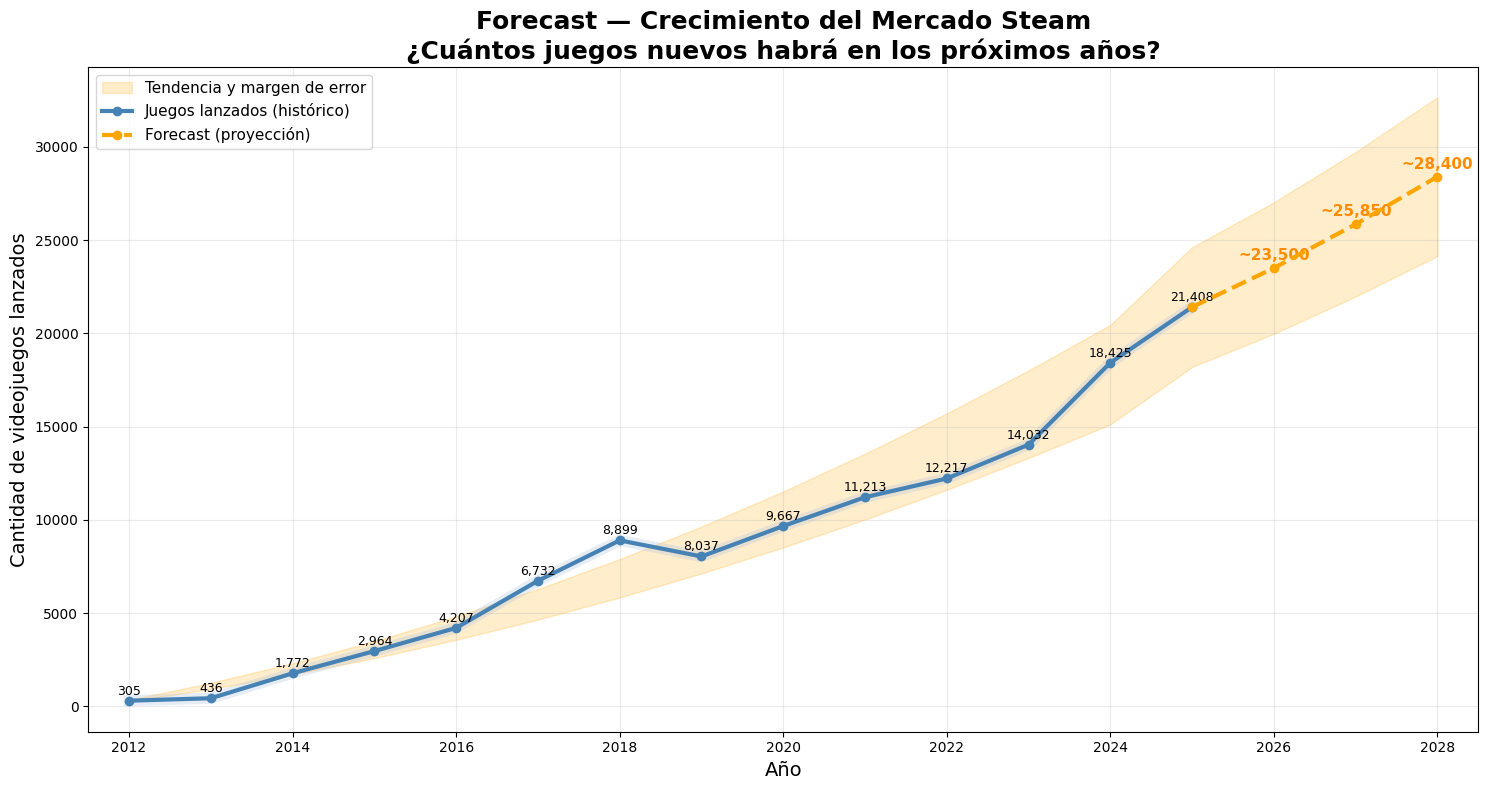

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# DATOS HISTÓRICOS ORIGINALES
# ==========================

años_original = [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
                 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
                 2022, 2023, 2024, 2025]

juegos_original = [60, 98, 170, 311, 260, 239, 305, 436,
                   1772, 2964, 4207, 6732, 8899, 8037,
                   9667, 11213, 12217, 14032, 18425, 21408]

# ==========================
# FORECAST
# ==========================

años_forecast = [2025, 2026, 2027, 2028]
forecast = [21408, 23500, 25850, 28400]

# Margen de error ±15%
error = np.array(forecast) * 0.15
lower = np.array(forecast) - error
upper = np.array(forecast) + error

# ==========================
# FILTRADO DE DATOS HISTÓRICOS DESDE 2012
# ==========================
start_year_display = 2012
idx_start_display = años_original.index(start_year_display)
años_display = años_original[idx_start_display:]
juegos_display = juegos_original[idx_start_display:]

# ==========================
# FIGURA
# ==========================

plt.figure(figsize=(15,8))

# ==========================
# BANDA DE TENDENCIA GENERAL Y FORECAST (unificada)
# ==========================

# Using a polynomial fit of degree 2 for the filtered data to better capture the trend
coef = np.polyfit(años_display, juegos_display, 2)
tendencia = np.poly1d(coef)

años_tendencia = np.arange(min(años_display), max(años_forecast)+1) # Full range for shadow
valores_tendencia = tendencia(años_tendencia)

# Create combined lower and upper bounds for the unified shadow
combined_lower_y = []
combined_upper_y = []

for year_val in años_tendencia:
    if year_val < años_forecast[0]:  # Historical trend part (before 2025)
        idx = list(años_tendencia).index(year_val)
        combined_lower_y.append(valores_tendencia[idx] * 0.85)
        combined_upper_y.append(valores_tendencia[idx] * 1.15)
    else:  # Forecast part (from 2025 onwards)
        idx_forecast = años_forecast.index(year_val)
        combined_lower_y.append(lower[idx_forecast])
        combined_upper_y.append(upper[idx_forecast])

plt.fill_between(
    años_tendencia,
    combined_lower_y,
    combined_upper_y,
    color='orange',
    alpha=0.20,
    label='Tendencia y margen de error',
    zorder=0
)

# ==========================
# SOMBRA DE LA LÍNEA HISTÓRICA
# ==========================

plt.plot(
    años_display,
    juegos_display,
    linewidth=8,
    color='lightsteelblue',
    alpha=0.30,
    zorder=1
)

# ==========================
# LÍNEA HISTÓRICA
# ==========================

plt.plot(
    años_display,
    juegos_display,
    marker='o',
    linewidth=3,
    color='steelblue',
    label='Juegos lanzados (histórico)',
    zorder=3
)

# ==========================
# FORECAST
# ==========================

plt.plot(
    años_forecast,
    forecast,
    marker='o',
    linestyle='--',
    linewidth=3,
    color='orange',
    label='Forecast (proyección)',
    zorder=4
)

# ==========================
# ETIQUETAS HISTÓRICAS
# ==========================

for x, y in zip(años_display, juegos_display):
    plt.text(
        x,
        y + max(juegos_original)*0.015, # Using original max for consistent scaling
        f'{y:,}',
        ha='center',
        fontsize=9
    )

# ==========================
# ETIQUETAS FORECAST
# ==========================

for x, y in zip(años_forecast[1:], forecast[1:]):
    plt.text(
        x,
        y + max(juegos_original)*0.02, # Using original max for consistent scaling
        f'~{y:,}',
        ha='center',
        fontsize=11,
        color='darkorange',
        fontweight='bold'
    )

# ==========================
# FORMATO GENERAL
# ==========================

plt.title(
    'Forecast — Crecimiento del Mercado Steam\n¿Cuántos juegos nuevos habrá en los próximos años?',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Año', fontsize=14)
plt.ylabel('Cantidad de videojuegos lanzados', fontsize=14)

plt.grid(True, alpha=0.25)

plt.legend(fontsize=11)
plt.xlim(start_year_display - 0.5, max(años_forecast) + 0.5) # Set x-axis limits to start from 2012
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# FORECAST — PORCENTAJE DE JUEGOS GRATUITOS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Cargar dataset
df = pd.read_csv("games_dataset.csv", encoding="utf-8")

# Obtener año
df["year"] = pd.to_datetime(df["date_release"], errors="coerce").dt.year

# Nos quedamos con años razonables
df = df[df["year"].between(2010, 2022)]

# ------------------------------------------------
# Crear variable: juego gratuito
# ------------------------------------------------
# Se considera gratuito si el precio final es 0

df["gratis"] = df["price_final"] == 0

# ------------------------------------------------
# Calcular porcentaje de gratuitos por año
# ------------------------------------------------

resumen = (
    df.groupby("year")
      .agg(
          total=("gratis","count"),
          gratuitos=("gratis","sum")
      )
      .reset_index()
)

resumen["porcentaje"] = (
    resumen["gratuitos"] /
    resumen["total"] * 100
)

print(resumen)

    year  total  gratuitos  porcentaje
0   2010    284         14    4.929577
1   2011    376         21    5.585106
2   2012    565         36    6.371681
3   2013    822         51    6.204380
4   2014   1921        154    8.016658
5   2015   2963        316   10.664867
6   2016   4209        611   14.516512
7   2017   4989        857   17.177791
8   2018   5461       1015   18.586339
9   2019   5057        991   19.596599
10  2020   6135       1294   21.092095
11  2021   6774       1411   20.829643
12  2022   7265       1567   21.569167


In [ ]:
# ===========================
# Modelo lineal
# ===========================

X = resumen["year"].values.reshape(-1,1)
y = resumen["porcentaje"].values

modelo = LinearRegression()
modelo.fit(X,y)

# Forecast

años_futuros = np.array([2023,2024,2025]).reshape(-1,1)

pred = modelo.predict(años_futuros)

print("\nFORECAST\n")

for a,p in zip([2023,2024,2025],pred):
    print(f"{a}: {p:.2f}%")


FORECAST

2023: 25.12%
2024: 26.78%
2025: 28.44%


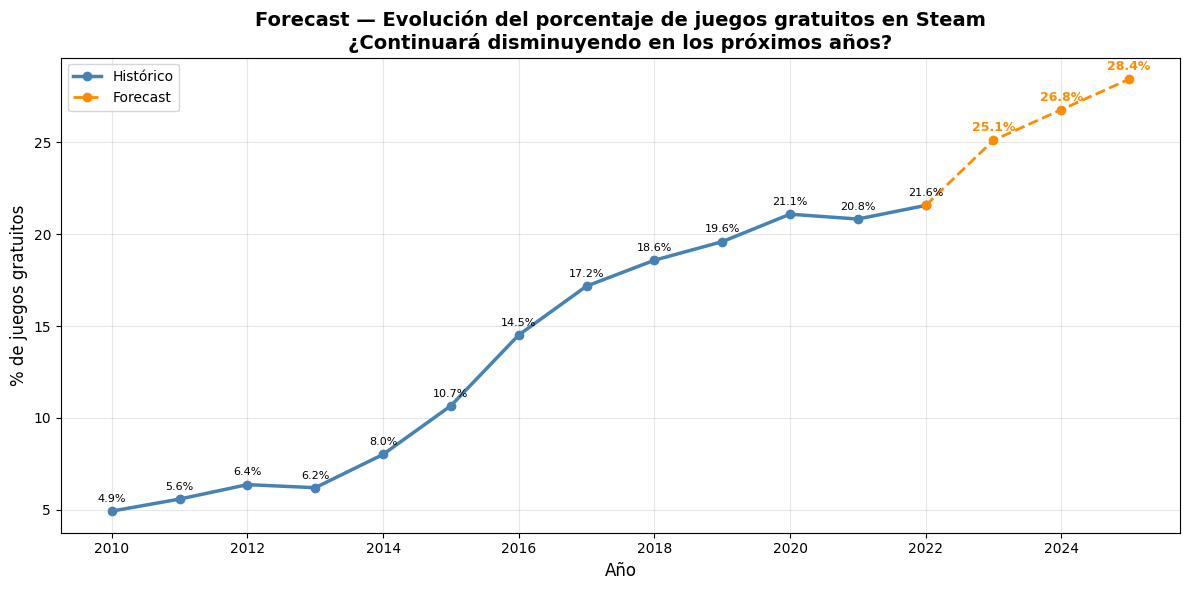

In [ ]:
# ===========================
# Gráfico
# ===========================

plt.figure(figsize=(12,6))

# Histórico
plt.plot(
    resumen["year"],
    resumen["porcentaje"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
    label="Histórico"
)

# Forecast
plt.plot(
    [2022,2023,2024,2025],
    [resumen["porcentaje"].iloc[-1]] + list(pred),
    marker="o",
    linestyle="--",
    linewidth=2,
    color="darkorange",
    label="Forecast"
)

# Etiquetas

for x,y in zip(resumen["year"],resumen["porcentaje"]):
    plt.text(x,y+0.5,f"{y:.1f}%",ha="center",fontsize=8)

for x,y in zip([2023,2024,2025],pred):
    plt.text(x,y+0.5,f"{y:.1f}%",ha="center",
             fontsize=9,
             color="darkorange",
             fontweight="bold")

plt.grid(alpha=0.3)

plt.xlabel("Año",fontsize=12)
plt.ylabel("% de juegos gratuitos",fontsize=12)

plt.title(
    "Forecast — Evolución del porcentaje de juegos gratuitos en Steam\n"
    "¿Continuará disminuyendo en los próximos años?",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("games_dataset.csv")

df["year"] = pd.to_datetime(
    df["date_release"],
    errors="coerce"
).dt.year

df = df[df["year"].between(2010,2022)]

variables = [
    "user_reviews",
    "positive_ratio",
    "price_final",
    "price_original",
    "discount"
]

for var in variables:
    print("\n==========================")
    print(var)
    print("==========================")
    print(df.groupby("year")[var].mean())


user_reviews
year
2010     3559.475352
2011     5535.244681
2012    17392.336283
2013     7667.491484
2014     1894.578865
2015     2538.823490
2016     1730.945355
2017     1939.077370
2018     1570.364402
2019     1328.455606
2020     1470.975713
2021     1032.881754
2022      881.533655
Name: user_reviews, dtype: float64

positive_ratio
year
2010    75.563380
2011    74.651596
2012    75.543363
2013    75.709246
2014    72.164498
2015    72.724603
2016    73.341649
2017    73.430347
2018    74.489837
2019    76.854855
2020    78.631133
2021    80.233835
2022    80.420234
Name: positive_ratio, dtype: float64

price_final
year
2010    8.366303
2011    8.433165
2012    9.510566
2013    9.757214
2014    9.033061
2015    7.833925
2016    7.571791
2017    7.676552
2018    7.615424
2019    8.339868
2020    8.459524
2021    8.439894
2022    9.917744
Name: price_final, dtype: float64

price_original
year
2010     8.487113
2011     8.270000
2012     9.676513
2013    10.031448
2014     9.3979

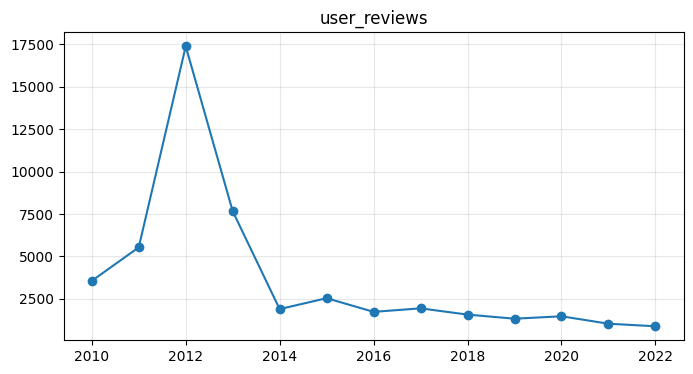

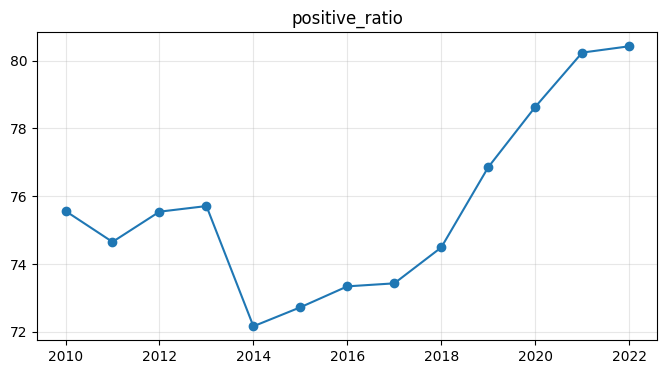

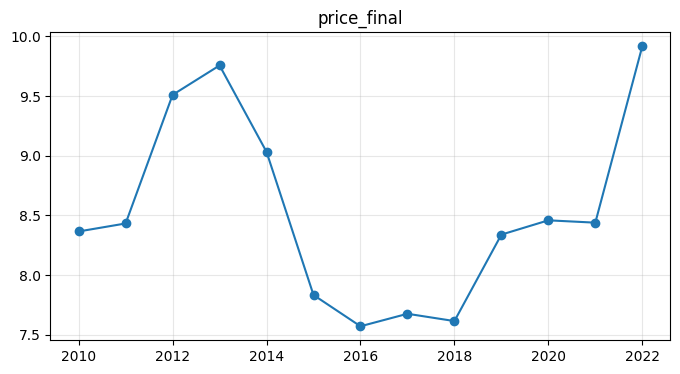

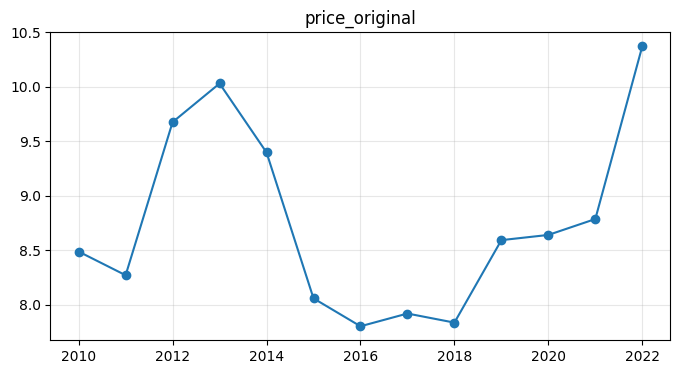

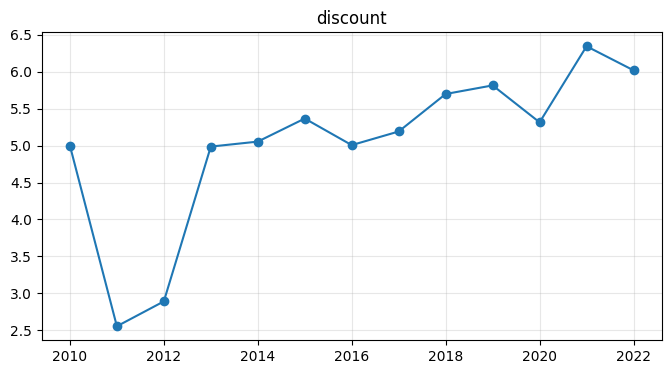

In [ ]:
import matplotlib.pyplot as plt

variables = [
    "user_reviews",
    "positive_ratio",
    "price_final",
    "price_original",
    "discount"
]

for var in variables:

    serie = df.groupby("year")[var].mean()

    plt.figure(figsize=(8,4))
    plt.plot(
        serie.index,
        serie.values,
        marker="o"
    )

    plt.title(var)
    plt.grid(alpha=0.3)
    plt.show()

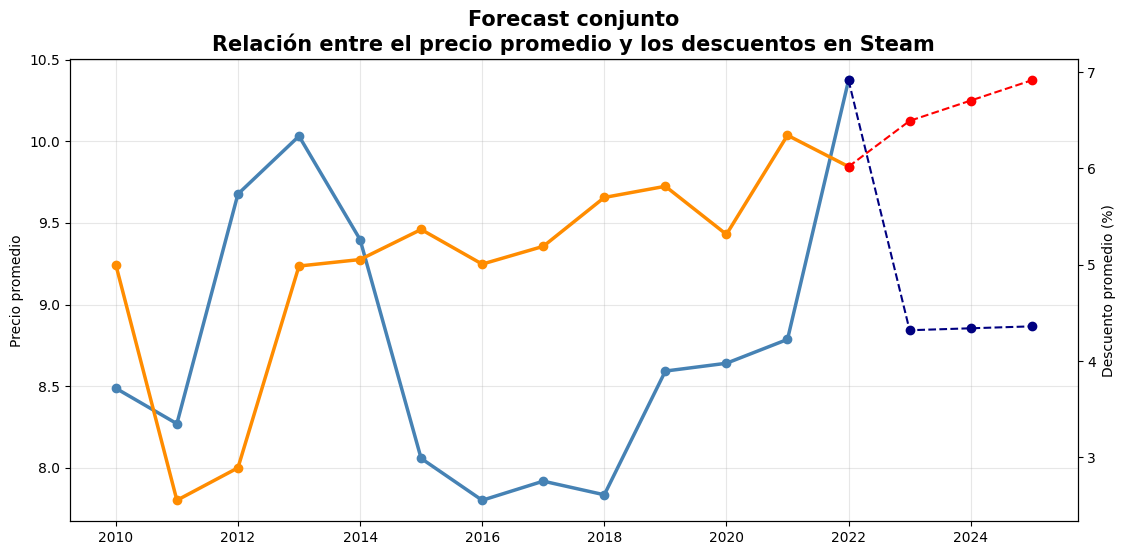

In [ ]:
# ============================================================
# FORECAST COMBINADO
# Precio promedio vs Descuento promedio
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("games_dataset.csv", encoding="utf-8")

df["year"] = pd.to_datetime(
    df["date_release"],
    errors="coerce"
).dt.year

df = df[df["year"].between(2010,2022)]

# Promedios por año

resumen = (
    df.groupby("year")
      .agg({
          "price_original":"mean",
          "discount":"mean"
      })
      .reset_index()
)

#-----------------------
# Modelos
#-----------------------

X = resumen[["year"]]

modelo_precio = LinearRegression()
modelo_desc = LinearRegression()

modelo_precio.fit(X,resumen["price_original"])
modelo_desc.fit(X,resumen["discount"])

años_futuros = pd.DataFrame({
    "year":[2023,2024,2025]
})

pred_precio = modelo_precio.predict(años_futuros)
pred_desc = modelo_desc.predict(años_futuros)

#-----------------------
# Gráfico
#-----------------------

fig,ax1 = plt.subplots(figsize=(13,6))

# Precio

ax1.plot(
    resumen["year"],
    resumen["price_original"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
    label="Precio original promedio"
)

ax1.plot(
    [2022,2023,2024,2025],
    [resumen["price_original"].iloc[-1]]+list(pred_precio),
    "--o",
    color="navy"
)

ax1.set_ylabel("Precio promedio")

# Segundo eje

ax2=ax1.twinx()

ax2.plot(
    resumen["year"],
    resumen["discount"],
    marker="o",
    linewidth=2.5,
    color="darkorange",
    label="Descuento promedio"
)

ax2.plot(
    [2022,2023,2024,2025],
    [resumen["discount"].iloc[-1]]+list(pred_desc),
    "--o",
    color="red"
)

ax2.set_ylabel("Descuento promedio (%)")

plt.title(
    "Forecast conjunto\n"
    "Relación entre el precio promedio y los descuentos en Steam",
    fontsize=15,
    fontweight="bold"
)

ax1.grid(alpha=.3)

plt.show()

In [ ]:
# ============================================================
# KPIs AVANZADOS — RPO / TTT / RRG / ILC
# Merge entre steam_games_500_2026 y games_dataset
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ── CARGA Y MERGE ────────────────────────────────────────
df1 = pd.read_csv("steam_games_500_2026.csv", sep=';', encoding='latin-1', decimal=',')
df2 = pd.read_csv("games_dataset.csv", encoding='utf-8')

df1['AppID']          = pd.to_numeric(df1['AppID'],          errors='coerce')
df2['app_id']         = pd.to_numeric(df2['app_id'],         errors='coerce')
df2['user_reviews']   = pd.to_numeric(df2['user_reviews'],   errors='coerce')
df2['positive_ratio'] = pd.to_numeric(df2['positive_ratio'], errors='coerce')

# Merge inner: solo los 282 juegos presentes en ambos datasets
df = pd.merge(
    df1, df2[['app_id','user_reviews','positive_ratio','rating',
              'win','mac','linux','steam_deck']],
    left_on='AppID', right_on='app_id', how='inner'
)

print(f"Dataset combinado: {len(df)} juegos")

# ── REVENUE (base para RPO y RRG) ────────────────────────
ARPU_base = {"Action":13,"Adventure":9,"RPG":20,"Strategy":13,
             "Simulation":8,"Casual":6,"Massively Multiplayer":22,
             "Indie":7,"Sports":11,"Racing":9}
df['ARPU'] = df['Primary_Genre'].map(ARPU_base).fillna(10)
df = df[df['Total_Reviews'] > 0].copy()
df['Revenue'] = df['Estimated_Owners'] * df['Price_USD']
free = df['Price_USD'] == 0
df.loc[free, 'Revenue'] = df.loc[free, 'Estimated_Owners'] * df.loc[free, 'ARPU']

# ── FECHA Y ANTIGÜEDAD ───────────────────────────────────
df['Release_Date'] = pd.to_datetime(df['Release_Date'], dayfirst=True, errors='coerce')
df['años_en_mercado'] = ((pd.Timestamp('2026-01-01') - df['Release_Date'])
                          .dt.days / 365.25).round(2)
df = df[df['años_en_mercado'] > 0].copy()

print(f"Juegos con fecha válida: {len(df)}")
print("─" * 55)

Dataset combinado: 282 juegos
Juegos con fecha válida: 280
───────────────────────────────────────────────────────


TOP 10 — KPI N°2: Revenue por Owner (RPO)
                                Name Primary_Genre  Price_USD      Revenue  Estimated_Owners  user_reviews   RPO
           STAR WARS Jedi: Survivor        Action      69.99  171499296.6           2450340         33280 69.99
             Need for Speed Unbound        Action      69.99  120825136.8           1726320         15199 69.99
                Need for Speed Heat        Action      69.99  310360856.4           4434360         69978 69.99
                           Starfield           RPG      69.99  363269097.0           5190300         28617 69.99
                     Hogwarts Legacy        Action      59.99  658335659.1          10974090        156547 59.99
      Marvels Spider-Man Remastered        Action      59.99  237470415.0           3958500         53844 59.99
  ARMORED CORE VI FIRES OF RUBICON        Action      59.99  149915010.0           2499000         32418 59.99
                      Cyberpunk 2077           RPG    

/tmp/ipykernel_1554/3899894909.py:36: UserWarning:

Glyph 153 (\x99) missing from font(s) DejaVu Sans.

/tmp/ipykernel_1554/3899894909.py:36: UserWarning:

Glyph 146 (\x92) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 153 (\x99) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 146 (\x92) missing from font(s) DejaVu Sans.



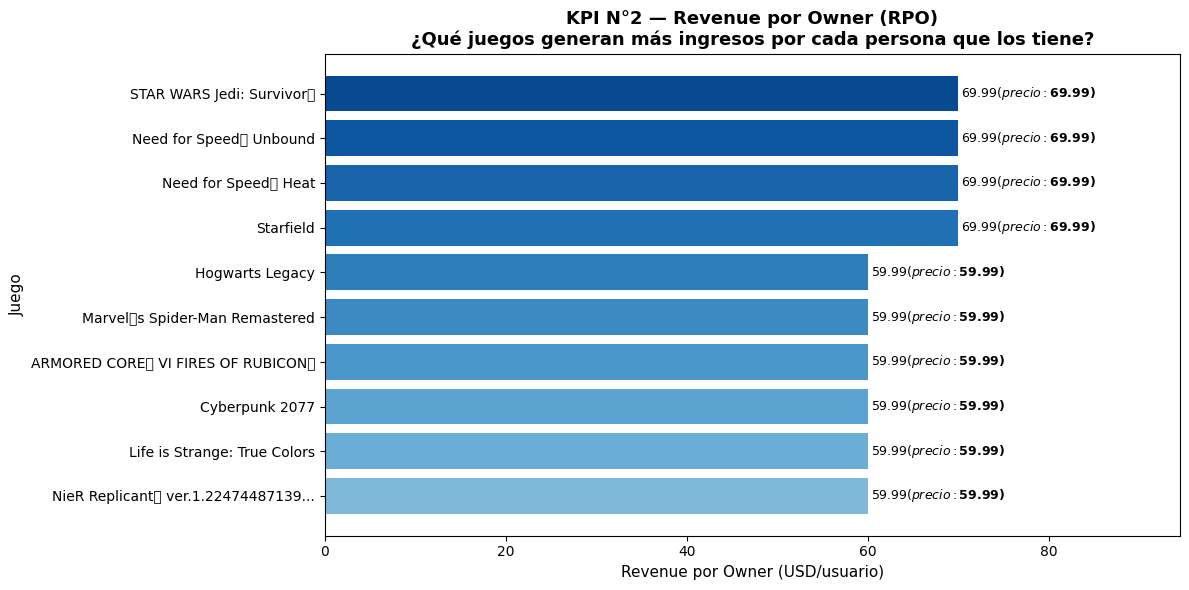


RPO promedio del mercado: $28.65
RPO mediano:              $24.99


In [ ]:
# ============================================================
# KPI N°2 — RPO (Revenue por Owner)
# Fórmula: Revenue / Estimated_Owners
# Mide: eficiencia económica por usuario
# Merge aporta: user_reviews de df2 para enriquecer el análisis
# ============================================================

df['RPO'] = (df['Revenue'] / df['Estimated_Owners']).round(2)

# Enriquecimiento con df2: añadimos user_reviews como contexto
# Un RPO alto con muchas user_reviews es más sólido que uno con pocas
df['RPO_confianza'] = np.log1p(df['user_reviews'])  # peso de confianza

top_rpo = df[['Name','Primary_Genre','Price_USD','Revenue',
              'Estimated_Owners','user_reviews','RPO']]\
    .sort_values('RPO', ascending=False).head(10)

print("TOP 10 — KPI N°2: Revenue por Owner (RPO)")
print(top_rpo.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colores = plt.cm.Blues(np.linspace(0.45, 0.9, 10))
bars = ax.barh(top_rpo['Name'][::-1], top_rpo['RPO'][::-1], color=colores)

for bar, val, precio in zip(bars, top_rpo['RPO'][::-1], top_rpo['Price_USD'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}  (precio: ${precio:.2f})',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, top_rpo['RPO'].max() * 1.35)
ax.set_xlabel('Revenue por Owner (USD/usuario)', fontsize=11)
ax.set_ylabel('Juego', fontsize=11)
ax.set_title('KPI N°2 — Revenue por Owner (RPO)\n'
             '¿Qué juegos generan más ingresos por cada persona que los tiene?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRPO promedio del mercado: ${df['RPO'].mean():.2f}")
print(f"RPO mediano:              ${df['RPO'].median():.2f}")

TOP 10 — KPI N°6: Tasa de Tracción Temprana (TTT)
                Name Primary_Genre  años_en_mercado  Total_Reviews  user_reviews      TTT
    Counter-Strike 2        Action            13.36        9581724       7494460 639078.8
Escape the Backrooms        Action             0.19         137858         31889 446702.6
 PUBG: BATTLEGROUNDS        Action             8.03        2708226       2217226 306690.6
     Baldur's Gate 3     Adventure             2.41         837240        269840 229684.6
          ELDEN RING        Action             3.85        1130569        528702 215489.8
       7 Days to Die        Action             1.44         398531        189374 204133.6
              Dota 2        Action            12.48        2706010       2045628 190370.1
       Call of Duty®        Action             3.18         769974        429206 188550.3
       Apex Legends        Action             5.16        1045332        713182 170398.7
        Satisfactory     Adventure             1.3

/tmp/ipykernel_1554/3144353738.py:39: UserWarning:

Glyph 153 (\x99) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 153 (\x99) missing from font(s) DejaVu Sans.



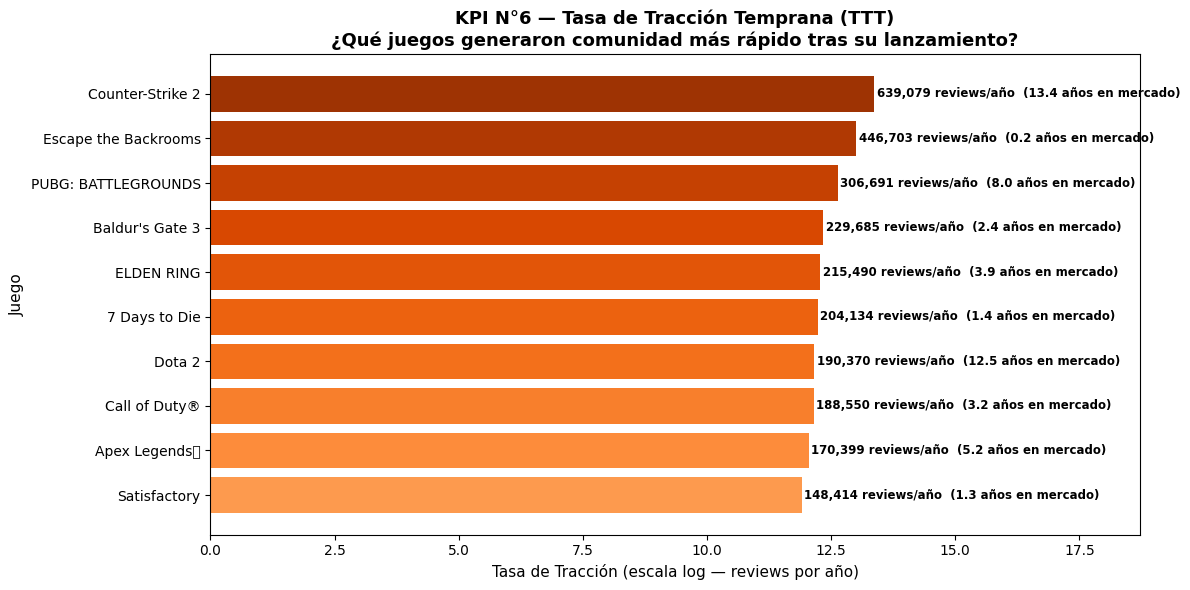


TTT promedio por género:
Primary_Genre
Casual                   40921.8
Action                   37091.4
Adventure                32378.0
Unknown                  22231.9
Indie                    19904.8
RPG                      15538.5
Simulation               15108.8
Strategy                 13900.2
Racing                    8678.3
Massively Multiplayer     5278.2


In [ ]:
# ============================================================
# KPI N°6 — TTT (Tasa de Tracción Temprana)
# Fórmula: Total_Reviews / años_en_mercado
# Mide: velocidad de adopción — cuántas reviews por año
# Merge aporta: user_reviews de df2 como segunda medición
# ============================================================

df['TTT_reviews_propios']  = (df['Total_Reviews']  / df['años_en_mercado']).round(1)
df['TTT_reviews_df2']      = (df['user_reviews']   / df['años_en_mercado']).round(1)

# Promedio entre las dos fuentes — más robusto que usar una sola
df['TTT'] = ((df['TTT_reviews_propios'] + df['TTT_reviews_df2']) / 2).round(1)

top_ttt = df[['Name','Primary_Genre','años_en_mercado',
              'Total_Reviews','user_reviews','TTT']]\
    .sort_values('TTT', ascending=False).head(10)

print("TOP 10 — KPI N°6: Tasa de Tracción Temprana (TTT)")
print(top_ttt.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colores = plt.cm.Oranges(np.linspace(0.45, 0.9, 10))
bars = ax.barh(top_ttt['Name'][::-1],
               np.log1p(top_ttt['TTT'][::-1]), color=colores)

# Etiqueta con el valor real (no el log)
for bar, val, años in zip(bars, top_ttt['TTT'][::-1],
                           top_ttt['años_en_mercado'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} reviews/año  ({años:.1f} años en mercado)',
            va='center', fontsize=8.5, fontweight='bold')

ax.set_xlim(0, np.log1p(top_ttt['TTT'].max()) * 1.4)
ax.set_xlabel('Tasa de Tracción (escala log — reviews por año)', fontsize=11)
ax.set_ylabel('Juego', fontsize=11)
ax.set_title('KPI N°6 — Tasa de Tracción Temprana (TTT)\n'
             '¿Qué juegos generaron comunidad más rápido tras su lanzamiento?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Por género
ttt_genero = df.groupby('Primary_Genre')['TTT'].mean().sort_values(ascending=False)
print("\nTTT promedio por género:")
print(ttt_genero.round(1).to_string())

In [ ]:
# ============================================================
# KPI N°9 — RRG (Rentabilidad Relativa al Género)
# Fórmula: Revenue_juego / Revenue_promedio_género
# Mide: qué tan por encima/debajo del promedio de su género está
# Merge aporta: positive_ratio de df2 para contextualizar
# ============================================================

revenue_promedio_genero = df.groupby('Primary_Genre')['Revenue'].transform('mean')
df['RRG'] = (df['Revenue'] / revenue_promedio_genero).round(3)

# RRG > 1 = supera al promedio de su género
# RRG = 2.5 = genera 2.5x más que el típico juego de su categoría

top_rrg = df[['Name','Primary_Genre','Revenue','RRG','positive_ratio']]\
    .sort_values('RRG', ascending=False).head(10)

print("TOP 10 — KPI N°9: Rentabilidad Relativa al Género (RRG)")
print(top_rrg.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colores = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10))
bars = ax.barh(top_rrg['Name'][::-1], top_rrg['RRG'][::-1], color=colores[::-1])

# Línea de referencia en 1.0 (promedio del género)
ax.axvline(x=1.0, color='black', linewidth=1.5, linestyle='--',
           label='Promedio del género (RRG = 1.0)')

for bar, val, genero in zip(bars, top_rrg['RRG'][::-1],
                             top_rrg['Primary_Genre'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x  [{genero}]',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, top_rrg['RRG'].max() * 1.3)
ax.set_xlabel('Múltiplo sobre el promedio del género', fontsize=11)
ax.set_ylabel('Juego', fontsize=11)
ax.set_title('KPI N°9 — Rentabilidad Relativa al Género (RRG)\n'
             'Compara juegos de distintos géneros en igualdad de condiciones',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Juegos que están por debajo del promedio de su género
debajo = df[df['RRG'] < 1.0]
print(f"\nJuegos por debajo del promedio de su género: {len(debajo)} ({len(debajo)/len(df)*100:.1f}%)")
print(f"Juegos que duplican o más el promedio (RRG ≥ 2): {(df['RRG'] >= 2).sum()}")

TOP 10 — KPI N°10: Índice de Longevidad Comercial (ILC)
                             Name Primary_Genre Release_Date  años_en_mercado  24h_Peak_Players  positive_ratio       ILC
                           IdleOn        Casual   2025-11-06             0.15             14880              76 661333.33
             Escape the Backrooms        Action   2025-10-23             0.19              5530              90 153185.60
                  Slime Rancher 2        Action   2025-09-23             0.27              1623              95  22263.37
                     Satisfactory     Adventure   2024-09-10             1.31             24962              97  14545.77
                    7 Days to Die        Action   2024-07-25             1.44             26034              88  12554.98
                       Overwatch®        Action   2023-08-10             2.40             65443               9  11361.63
              PUBG: BATTLEGROUNDS        Action   2017-12-21             8.03            7

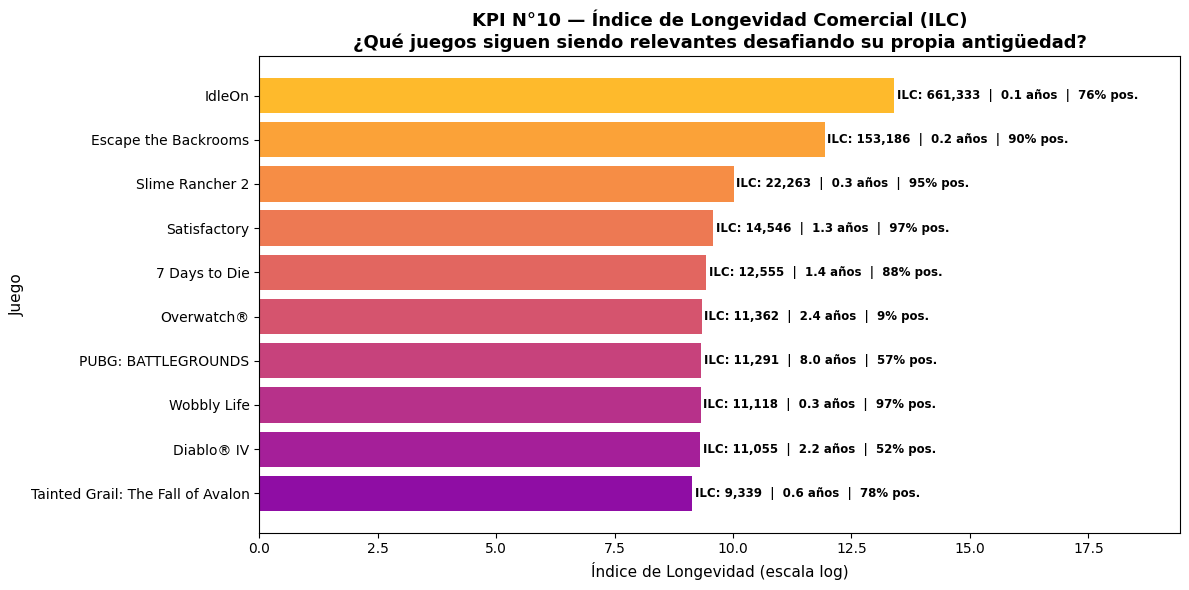


ILC promedio por género:
Primary_Genre
Casual                   73647.06
Unknown                   5972.91
Action                    1861.75
Adventure                 1445.98
Simulation                 726.54
Strategy                   433.15
RPG                        257.45
Indie                      251.59
Massively Multiplayer      109.81
Racing                     100.06


In [ ]:
# ============================================================
# KPI N°10 — ILC (Índice de Longevidad Comercial)
# Fórmula: 24h_Peak_Players / (años_en_mercado²)
# Mide: vigencia actual penalizada por la antigüedad del juego
# Merge aporta: user_reviews y positive_ratio de df2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ── CARGA Y MERGE ────────────────────────────────────────
df1 = pd.read_csv("steam_games_500_2026 (1).csv", sep=';', encoding='latin-1', decimal=',')
df2 = pd.read_csv("games_dataset.csv", encoding='utf-8')

df1['AppID']          = pd.to_numeric(df1['AppID'],          errors='coerce')
df2['app_id']         = pd.to_numeric(df2['app_id'],         errors='coerce')
df2['user_reviews']   = pd.to_numeric(df2['user_reviews'],   errors='coerce')
df2['positive_ratio'] = pd.to_numeric(df2['positive_ratio'], errors='coerce')

# Merge inner: solo los 282 juegos presentes en ambos datasets
df = pd.merge(
    df1, df2[['app_id','user_reviews','positive_ratio','rating',
              'win','mac','linux','steam_deck']],
    left_on='AppID', right_on='app_id', how='inner'
)

# ── REVENUE (base para RPO y RRG) ────────────────────────
ARPU_base = {"Action":13,"Adventure":9,"RPG":20,"Strategy":13,
             "Simulation":8,"Casual":6,"Massively Multiplayer":22,
             "Indie":7,"Sports":11,"Racing":9}
df['ARPU'] = df['Primary_Genre'].map(ARPU_base).fillna(10)
df = df[df['Total_Reviews'] > 0].copy()
df['Revenue'] = df['Estimated_Owners'] * df['Price_USD']
free = df['Price_USD'] == 0
df.loc[free, 'Revenue'] = df.loc[free, 'Estimated_Owners'] * df.loc[free, 'ARPU']

# ── FECHA Y ANTIGÜEDAD ───────────────────────────────────
df['Release_Date'] = pd.to_datetime(df['Release_Date'], dayfirst=True, errors='coerce')
df['años_en_mercado'] = ((pd.Timestamp('2026-01-01') - df['Release_Date'])
                          .dt.days / 365.25).round(2)
df = df[df['años_en_mercado'] > 0].copy()

# El cuadrado penaliza más a los juegos viejos con pocos jugadores
# Un juego de 2015 con 10.000 jugadores activos es más impresionante
# que uno de 2023 con los mismos jugadores
df['ILC'] = (df['24h_Peak_Players'] / (df['años_en_mercado'] ** 2)).round(2)

# Enriquecimiento con df2: añadimos positive_ratio para ver
# si los juegos longevos también mantienen buena reputación
top_ilc = df[['Name','Primary_Genre','Release_Date','años_en_mercado',
              '24h_Peak_Players','positive_ratio','ILC']].sort_values('ILC', ascending=False).head(10)

print("TOP 10 — KPI N°10: Índice de Longevidad Comercial (ILC)")
print(top_ilc.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
colores = plt.cm.plasma(np.linspace(0.3, 0.85, 10))
bars = ax.barh(top_ilc['Name'][::-1],
               np.log1p(top_ilc['ILC'][::-1]), color=colores)

for bar, val, años, ratio in zip(bars,
                                   top_ilc['ILC'][::-1],
                                   top_ilc['años_en_mercado'][::-1],
                                   top_ilc['positive_ratio'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'ILC: {val:,.0f}  |  {años:.1f} años  |  {ratio:.0f}% pos.',
            va='center', fontsize=8.5, fontweight='bold')

ax.set_xlim(0, np.log1p(top_ilc['ILC'].max()) * 1.45)
ax.set_xlabel('Índice de Longevidad (escala log)', fontsize=11)
ax.set_ylabel('Juego', fontsize=11)
ax.set_title('KPI N°10 — Índice de Longevidad Comercial (ILC)\n'
             '¿Qué juegos siguen siendo relevantes desafiando su propia antigüedad?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Por género: qué géneros producen juegos más longevos
ilc_genero = df.groupby('Primary_Genre')['ILC'].mean().sort_values(ascending=False)
print("\nILC promedio por género:")
print(ilc_genero.round(2).to_string())

### **Selección de Juegos para Visualización**

Abajo encontrarás una nueva celda `selected_games`. Puedes modificar esta lista para incluir los nombres de los juegos específicos que deseas visualizar en el gráfico RRG.

*   **Para ver juegos específicos**: Edita la lista `selected_games` con los nombres exactos de los juegos (ej. `["Game Name 1", "Game Name 2"]`).
*   **Para ver los 10 juegos principales por defecto**: Deja la lista `selected_games` vacía (ej. `[]`).

El gráfico se actualizará automáticamente con tu selección.

In [ ]:
# Modifica esta lista con los nombres de los juegos que deseas visualizar.
# Deja la lista vacía (ej. `[]`) para ver los 10 juegos principales por defecto.
selected_games = [] # @param {type: "raw"}

In [ ]:
ilc_genero = (
    df.groupby('Primary_Genre')['ILC']
      .mean()
      .sort_values(ascending=False)
)

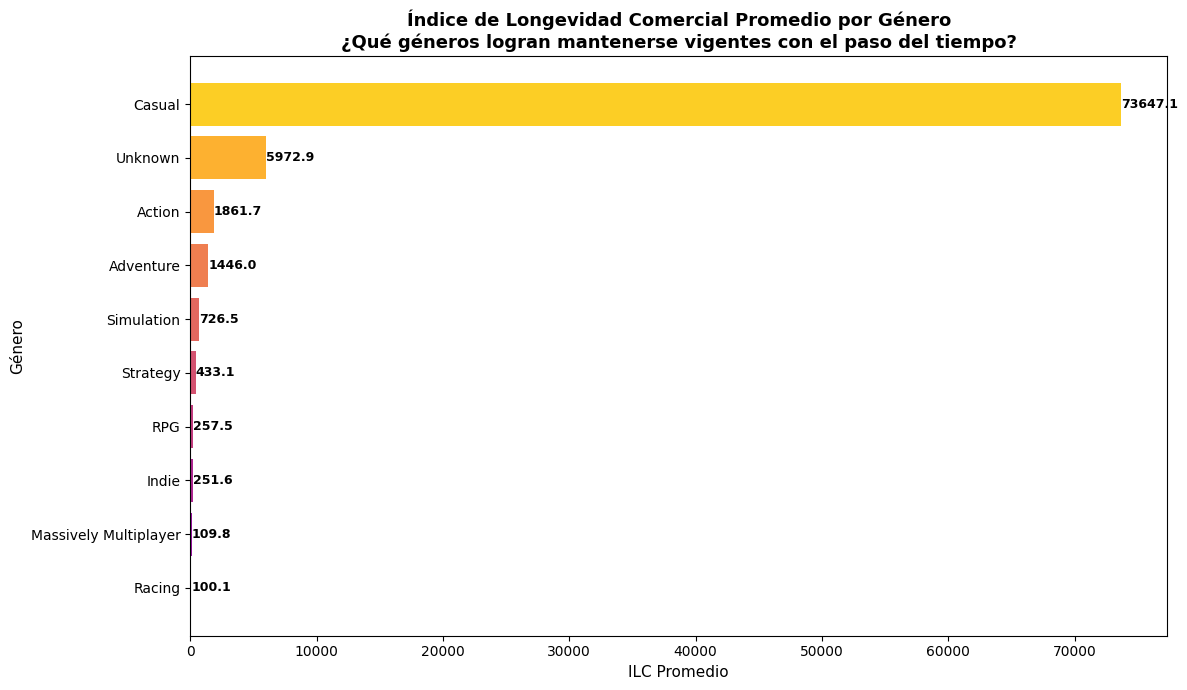

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))

colores = plt.cm.plasma(np.linspace(0.25,0.9,len(ilc_genero)))

bars = ax.barh(
    ilc_genero.index[::-1],
    ilc_genero.values[::-1],
    color=colores
)

for bar, valor in zip(bars, ilc_genero.values[::-1]):
    ax.text(
        bar.get_width()+0.2,
        bar.get_y()+bar.get_height()/2,
        f"{valor:.1f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xlabel("ILC Promedio", fontsize=11)
ax.set_ylabel("Género", fontsize=11)

ax.set_title(
    "Índice de Longevidad Comercial Promedio por Género\n"
    "¿Qué géneros logran mantenerse vigentes con el paso del tiempo?",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
ilc_genero = (
    df.groupby('Primary_Genre')['ILC']
      .median()
      .sort_values(ascending=False)
)

In [ ]:
# ============================================================
# KPI N°9 — RRG INTERACTIVO (ESTILO ORIGINAL)
# ============================================================

import plotly.graph_objects as go
import plotly.express as px
import numpy as np

# ------------------------------------------------------------
# KPI
# ------------------------------------------------------------

revenue_promedio_genero = (
    df.groupby('Primary_Genre')['Revenue']
      .transform('mean')
)

df['RRG'] = (
    df['Revenue'] / revenue_promedio_genero
).round(3)

# Dynamic selection of games for RRG visualization
if selected_games:
    # Filter the DataFrame to include only the selected games
    filtered_rrg = df[df['Name'].isin(selected_games)].copy()
    if not filtered_rrg.empty:
        # Sort the selected games by RRG for consistent display
        top_rrg = filtered_rrg[['Name','Primary_Genre','Revenue','RRG','positive_ratio']].sort_values('RRG', ascending=False)
    else:
        print("No matching games found in your selection. Displaying default top 10 games by RRG.")
        top_rrg = df[['Name','Primary_Genre','Revenue','RRG','positive_ratio']].sort_values('RRG', ascending=False).head(10)
else:
    # Default behavior: show the top 10 games by RRG
    top_rrg = (
        df[['Name','Primary_Genre','Revenue','RRG','positive_ratio']]
        .sort_values('RRG', ascending=False)
        .head(10)
    )

# ------------------------------------------------------------
# ORDEN IGUAL AL GRÁFICO ORIGINAL
# ------------------------------------------------------------

plot_df = top_rrg.iloc[::-1].copy()

# ------------------------------------------------------------
# COLORES IGUALES AL MATPLOTLIB
# ------------------------------------------------------------

# Ensure cmap is only generated if plot_df is not empty
if not plot_df.empty:
    cmap = px.colors.sample_colorscale(
        "RdYlGn",
        np.linspace(0.30, 0.90, len(plot_df))
    )
else:
    cmap = [] # Provide an empty list or default color if plot_df is empty

# ------------------------------------------------------------
# BARRAS
# ------------------------------------------------------------

fig = go.Figure()

# Only add trace if plot_df is not empty
if not plot_df.empty:
    fig.add_trace(
        go.Bar(
            x=plot_df["RRG"],
            y=plot_df["Name"],

            orientation="h",

            marker=dict(
                color=cmap[::-1] if cmap else 'blue' # Fallback color if cmap is empty
            ),

            text=[
                f"{rrg:.2f}x [{gen}]"
                for rrg, gen in zip(
                    plot_df["RRG"],
                    plot_df["Primary_Genre"]
                )
            ],

            textposition="outside",

            hovertemplate=
            "<b>%{y}</b><br>" +
            "RRG: %{x:.2f}x<br>" +
            "Género: %{customdata[0]}<br>" +
            "Revenue: $%{customdata[1]:,.0f}<br>" +
            "Positive Ratio: %{customdata[2]:.1f}%<br>" +
            "<extra></extra>",

            customdata=np.stack(
                [
                    plot_df["Primary_Genre"],
                    plot_df["Revenue"],
                    plot_df["positive_ratio"]
                ],
                axis=-1
            )
        )
    )

# ------------------------------------------------------------
# LINEA RRG = 1
# ------------------------------------------------------------

fig.add_vline(
    x=1,
    line_dash="dash",
    line_color="black",
    line_width=3
)

# ------------------------------------------------------------
# ESTILO
# ------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "<b>KPI N°9 — Rentabilidad Relativa al Género (RRG)</b>"
            "<br>"
            "Compara juegos de distintos géneros en igualdad de condiciones"
        ),
        x=0.5
    ),

    xaxis_title="Múltiplo sobre el promedio del género",

    yaxis_title="Juego",

    template="plotly_white",

    height=750,

    showlegend=False,

    margin=dict(
        l=50,
        r=120,
        t=90,
        b=50
    )
)

# Adjust x-axis range dynamically based on top_rrg, or a default if empty
if not top_rrg.empty:
    max_rrg_for_range = top_rrg["RRG"].max()
    fig.update_xaxes(
        range=[0, max_rrg_for_range * 1.3]
    )
else:
    fig.update_xaxes(
        range=[0, 2.0] # Default range if no games are plotted
    )

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

fig.show(
    config={
        "displayModeBar": True,
        "scrollZoom": True
    }
)

In [ ]:
# ============================================================
# KPI N°9 — RRG INTERACTIVO (ESTILO ORIGINAL)
# ============================================================

import plotly.graph_objects as go
import plotly.express as px
import numpy as np

# ------------------------------------------------------------
# KPI
# ------------------------------------------------------------

revenue_promedio_genero = (
    df.groupby('Primary_Genre')['Revenue']
      .transform('mean')
)

df['RRG'] = (
    df['Revenue'] / revenue_promedio_genero
).round(3)

top_rrg = (
    df[['Name','Primary_Genre','Revenue','RRG','positive_ratio']]
    .sort_values('RRG', ascending=False)
    .head(10)
)

# ------------------------------------------------------------
# ORDEN IGUAL AL GRÁFICO ORIGINAL
# ------------------------------------------------------------

plot_df = top_rrg.iloc[::-1].copy()

# ------------------------------------------------------------
# COLORES IGUALES AL MATPLOTLIB
# ------------------------------------------------------------

cmap = px.colors.sample_colorscale(
    "RdYlGn",
    np.linspace(0.30, 0.90, len(plot_df))
)

# ------------------------------------------------------------
# BARRAS
# ------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=plot_df["RRG"],
        y=plot_df["Name"],

        orientation="h",

        marker=dict(
            color=cmap[::-1]
        ),

        text=[
            f"{rrg:.2f}x [{gen}]"
            for rrg, gen in zip(
                plot_df["RRG"],
                plot_df["Primary_Genre"]
            )
        ],

        textposition="outside",

        hovertemplate=
        "<b>%{y}</b><br>" +
        "RRG: %{x:.2f}x<br>" +
        "Género: %{customdata[0]}<br>" +
        "Revenue: $%{customdata[1]:,.0f}<br>" +
        "Positive Ratio: %{customdata[2]:.1f}%<br>" +
        "<extra></extra>",

        customdata=np.stack(
            [
                plot_df["Primary_Genre"],
                plot_df["Revenue"],
                plot_df["positive_ratio"]
            ],
            axis=-1
        )
    )
)

# ------------------------------------------------------------
# LINEA RRG = 1
# ------------------------------------------------------------

fig.add_vline(
    x=1,
    line_dash="dash",
    line_color="black",
    line_width=3
)

# ------------------------------------------------------------
# ESTILO
# ------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "<b>KPI N°9 — Rentabilidad Relativa al Género (RRG)</b>"
            "<br>"
            "Compara juegos de distintos géneros en igualdad de condiciones"
        ),
        x=0.5
    ),

    xaxis_title="Múltiplo sobre el promedio del género",

    yaxis_title="Juego",

    template="plotly_white",

    height=750,

    showlegend=False,

    margin=dict(
        l=50,
        r=120,
        t=90,
        b=50
    )
)

fig.update_xaxes(
    range=[0, top_rrg["RRG"].max()*1.3]
)

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

fig.show(
    config={
        "displayModeBar": True,
        "scrollZoom": True
    }
)

KeyError: 'Primary_Genre'

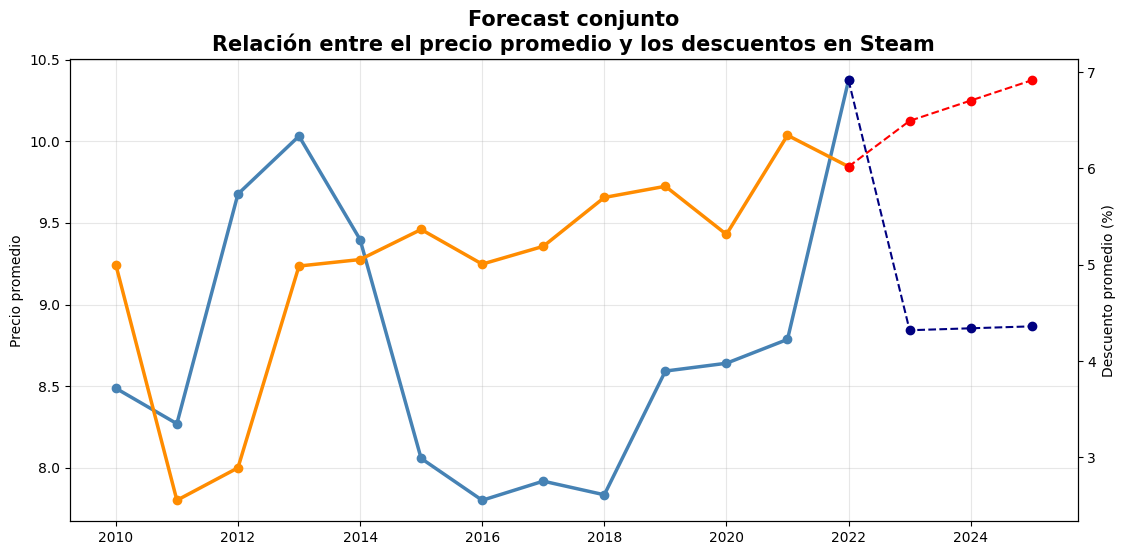

In [ ]:
# ============================================================

# FORECAST COMBINADO

# Precio promedio vs Descuento promedio

# ============================================================



import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression



df = pd.read_csv("games_dataset.csv", encoding="utf-8")



df["year"] = pd.to_datetime(

    df["date_release"],

    errors="coerce"

).dt.year



df = df[df["year"].between(2010,2022)]



# Promedios por año



resumen = (

    df.groupby("year")

      .agg({

          "price_original":"mean",

          "discount":"mean"

      })

      .reset_index()

)



#-----------------------

# Modelos

#-----------------------



X = resumen[["year"]]



modelo_precio = LinearRegression()

modelo_desc = LinearRegression()



modelo_precio.fit(X,resumen["price_original"])

modelo_desc.fit(X,resumen["discount"])



años_futuros = pd.DataFrame({

    "year":[2023,2024,2025]

})



pred_precio = modelo_precio.predict(años_futuros)

pred_desc = modelo_desc.predict(años_futuros)



#-----------------------

# Gráfico

#-----------------------



fig,ax1 = plt.subplots(figsize=(13,6))



# Precio



ax1.plot(

    resumen["year"],

    resumen["price_original"],

    marker="o",

    linewidth=2.5,

    color="steelblue",

    label="Precio original promedio"

)



ax1.plot(

    [2022,2023,2024,2025],

    [resumen["price_original"].iloc[-1]]+list(pred_precio),

    "--o",

    color="navy"

)



ax1.set_ylabel("Precio promedio")



# Segundo eje



ax2=ax1.twinx()



ax2.plot(

    resumen["year"],

    resumen["discount"],

    marker="o",

    linewidth=2.5,

    color="darkorange",

    label="Descuento promedio"

)



ax2.plot(

    [2022,2023,2024,2025],

    [resumen["discount"].iloc[-1]]+list(pred_desc),

    "--o",

    color="red"

)



ax2.set_ylabel("Descuento promedio (%)")



plt.title(

    "Forecast conjunto\n"

    "Relación entre el precio promedio y los descuentos en Steam",

    fontsize=15,

    fontweight="bold"

)



ax1.grid(alpha=.3)



plt.show()

In [ ]:
# ============================================================
# FORECAST COMBINADO INTERACTIVO
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

#-----------------------
# Cargar datos
#-----------------------

df = pd.read_csv("games_dataset.csv", encoding="utf-8")

df["year"] = pd.to_datetime(
    df["date_release"],
    errors="coerce"
).dt.year

df = df[df["year"].between(2010,2022)]

#-----------------------
# Resumen
#-----------------------

resumen = (
    df.groupby("year")
      .agg({
          "price_original":"mean",
          "discount":"mean"
      })
      .reset_index()
)

#-----------------------
# Modelos
#-----------------------

X = resumen[["year"]]

modelo_precio = LinearRegression()
modelo_desc = LinearRegression()

modelo_precio.fit(X,resumen["price_original"])
modelo_desc.fit(X,resumen["discount"])

años_futuros=[2023,2024,2025]

future=pd.DataFrame({
    "year":años_futuros
})

pred_precio=modelo_precio.predict(future)
pred_desc=modelo_desc.predict(future)

#=============================
# FIGURA
#=============================

fig=go.Figure()

# Histórico precio

fig.add_trace(
    go.Scatter(
        x=resumen["year"],
        y=resumen["price_original"],
        mode="lines+markers",
        name="Precio Original",
        line=dict(color="#00E5FF",width=4),
        marker=dict(size=10,color="#00E5FF"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Precio promedio: %{y:.2f}<extra></extra>"
    )
)

# Forecast precio

fig.add_trace(
    go.Scatter(
        x=[2022]+años_futuros,
        y=[resumen["price_original"].iloc[-1]]+list(pred_precio),
        mode="lines+markers",
        name="Forecast Precio",
        line=dict(color="#00E5FF",width=4,dash="dash"),
        marker=dict(size=10,color="#7DF9FF"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Forecast: %{y:.2f}<extra></extra>"
    )
)

# Histórico descuento

fig.add_trace(
    go.Scatter(
        x=resumen["year"],
        y=resumen["discount"],
        mode="lines+markers",
        name="Descuento",
        yaxis="y2",
        line=dict(color="#FF9800",width=4),
        marker=dict(size=10,color="#FFD54F"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Descuento: %{y:.2f}%<extra></extra>"
    )
)

# Forecast descuento

fig.add_trace(
    go.Scatter(
        x=[2022]+años_futuros,
        y=[resumen["discount"].iloc[-1]]+list(pred_desc),
        mode="lines+markers",
        name="Forecast Descuento",
        yaxis="y2",
        line=dict(color="#FF1744",width=4,dash="dash"),
        marker=dict(size=10,color="#FF4081"),
        hovertemplate=
        "<b>Año %{x}</b><br>"+
        "Forecast: %{y:.2f}%<extra></extra>"
    )
)

#=============================
# Diseño
#=============================

fig.update_layout(

    title={
        "text":"<b>📊 Forecast Conjunto Steam</b><br><sup>Relación entre Precio Original y Descuento Promedio</sup>",
        "x":0.5
    },

    template="plotly_dark",

    paper_bgcolor="#000000",
    plot_bgcolor="#000000",

    hovermode="x unified",

    xaxis=dict(
        title="Año",
        showgrid=True,
        gridcolor="rgba(255,255,255,0.1)"
    ),

    yaxis=dict(
        title="Precio Original",
        color="#00E5FF"
    ),

    yaxis2=dict(
        title="Descuento (%)",
        overlaying="y",
        side="right",
        color="#FF9800"
    ),

    legend=dict(
        orientation="h",
        y=1.12,
        x=0.15
    ),

    font=dict(
        family="Arial",
        size=14,
        color="white"
    ),

    width=1200,
    height=650
)

fig.show()

In [ ]:
# ============================================================
# KPI N°9 — RRG INTERACTIVO (ESTILO ORIGINAL)
# ============================================================

import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd

# Ensure 'selected_games' is defined, providing a default if not set elsewhere.
# This makes the cell self-contained and prevents NameError if the user doesn't run the `selected_games` cell.
if 'selected_games' not in locals() and 'selected_games' not in globals():
    selected_games = []

# ------------------------------------------------------------
# Ensure df is correctly loaded and processed for KPI calculations
# (Copied from CKlMWgSxixR_ to make this cell self-contained)
# ------------------------------------------------------------
df1 = pd.read_csv("steam_games_500_2026.csv", sep=';', encoding='latin-1', decimal=',')
df2 = pd.read_csv("games_dataset.csv", encoding='utf-8')

df1['AppID']          = pd.to_numeric(df1['AppID'],          errors='coerce')
df2['app_id']         = pd.to_numeric(df2['app_id'],         errors='coerce')
df2['user_reviews']   = pd.to_numeric(df2['user_reviews'],   errors='coerce')
df2['positive_ratio'] = pd.to_numeric(df2['positive_ratio'], errors='coerce')

# Merge inner: solo los 282 juegos presentes en ambos datasets
df = pd.merge(
    df1, df2[['app_id','user_reviews','positive_ratio','rating',
              'win','mac','linux','steam_deck']],
    left_on='AppID', right_on='app_id', how='inner'
)

# ── REVENUE (base para RPO y RRG) ────────────────────────
ARPU_base = {"Action":13,"Adventure":9,"RPG":20,"Strategy":13,
             "Simulation":8,"Casual":6,"Massively Multiplayer":22,
             "Indie":7,"Sports":11,"Racing":9}
df['ARPU'] = df['Primary_Genre'].map(ARPU_base).fillna(10)
df = df[df['Total_Reviews'] > 0].copy()
df['Revenue'] = df['Estimated_Owners'] * df['Price_USD']
free = df['Price_USD'] == 0
df.loc[free, 'Revenue'] = df.loc[free, 'Estimated_Owners'] * df.loc[free, 'ARPU']

# ── FECHA Y ANTIGÜEDAD ───────────────────────────────────
df['Release_Date'] = pd.to_datetime(df['Release_Date'], dayfirst=True, errors='coerce')
df['años_en_mercado'] = ((pd.Timestamp('2026-01-01') - df['Release_Date'])
                          .dt.days / 365.25).round(2)
df = df[df['años_en_mercado'] > 0].copy()

# ------------------------------------------------------------
# KPI
# ------------------------------------------------------------

revenue_promedio_genero = (
    df.groupby('Primary_Genre')['Revenue']
      .transform('mean')
)

df['RRG'] = (
    df['Revenue'] / revenue_promedio_genero
).round(3)

# Dynamic selection of games for RRG visualization
if selected_games:
    # Filter the DataFrame to include only the selected games
    filtered_rrg = df[df['Name'].isin(selected_games)].copy()
    if not filtered_rrg.empty:
        # Sort the selected games by RRG for consistent display
        top_rrg = filtered_rrg[['Name','Primary_Genre','Revenue','RRG','positive_ratio']].sort_values('RRG', ascending=False)
    else:
        print("No matching games found in your selection. Displaying default top 10 games by RRG.")
        top_rrg = df[['Name','Primary_Genre','Revenue','RRG','positive_ratio']].sort_values('RRG', ascending=False).head(10)
else:
    # Default behavior: show the top 10 games by RRG
    top_rrg = (
        df[['Name','Primary_Genre','Revenue','RRG','positive_ratio']]
        .sort_values('RRG', ascending=False)
        .head(10)
    )

# ------------------------------------------------------------
# ORDEN IGUAL AL GRÁFICO ORIGINAL
# ------------------------------------------------------------

plot_df = top_rrg.iloc[::-1].copy()

# ------------------------------------------------------------
# COLORES IGUALES AL MATPLOTLIB
# ------------------------------------------------------------

# Ensure cmap is only generated if plot_df is not empty
if not plot_df.empty:
    cmap = px.colors.sample_colorscale(
        "RdYlGn",
        np.linspace(0.30, 0.90, len(plot_df))
    )
else:
    cmap = [] # Provide an empty list or default color if plot_df is empty

# ------------------------------------------------------------
# BARRAS
# ------------------------------------------------------------

fig = go.Figure()

# Only add trace if plot_df is not empty
if not plot_df.empty:
    fig.add_trace(
        go.Bar(
            x=plot_df["RRG"],
            y=plot_df["Name"],

            orientation="h",

            marker=dict(
                color=cmap[::-1] if cmap else 'blue' # Fallback color if cmap is empty
            ),

            text=[
                f"{rrg:.2f}x [{gen}]"
                for rrg, gen in zip(
                    plot_df["RRG"],
                    plot_df["Primary_Genre"]
                )
            ],

            textposition="outside",

            hovertemplate=
            "<b>%{y}</b><br>" +
            "RRG: %{x:.2f}x<br>" +
            "Género: %{customdata[0]}<br>" +
            "Revenue: $%{customdata[1]:,.0f}<br>" +
            "Positive Ratio: %{customdata[2]:.1f}%<br>" +
            "<extra></extra>",

            customdata=np.stack(
                [
                    plot_df["Primary_Genre"],
                    plot_df["Revenue"],
                    plot_df["positive_ratio"]
                ],
                axis=-1
            )
        )
    )

# ------------------------------------------------------------
# LINEA RRG = 1
# ------------------------------------------------------------

fig.add_vline(
    x=1,
    line_dash="dash",
    line_color="black",
    line_width=3
)

# ------------------------------------------------------------
# ESTILO
# ------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "<b>KPI N°9 — Rentabilidad Relativa al Género (RRG)</b>"
            "<br>"
            "Compara juegos de distintos géneros en igualdad de condiciones"
        ),
        x=0.5
    ),

    xaxis_title="Múltiplo sobre el promedio del género",

    yaxis_title="Juego",

    template="plotly_white",

    height=750,

    showlegend=False,

    margin=dict(
        l=50,
        r=120,
        t=90,
        b=50
    )
)

# Adjust x-axis range dynamically based on top_rrg, or a default if empty
if not top_rrg.empty:
    max_rrg_for_range = top_rrg["RRG"].max()
    fig.update_xaxes(
        range=[0, max_rrg_for_range * 1.3]
    )
else:
    fig.update_xaxes(
        range=[0, 2.0] # Default range if no games are plotted
    )

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

fig.show(
    config={
        "displayModeBar": True,
        "scrollZoom": True
    }
)


FileNotFoundError: [Errno 2] No such file or directory: 'steam_games_500_2026.csv'

In [ ]:
# ============================================================
# SUBIR DATASET CSV A GOOGLE COLAB
# ============================================================

import pandas as pd
from google.colab import files

# Abrir explorador de archivos
uploaded = files.upload()

# Obtener nombre del archivo subido
archivo = list(uploaded.keys())[0]

# Leer CSV
df = pd.read_csv(archivo)

# Mostrar información
print(f"Archivo cargado: {archivo}")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Vista previa
display(df.head())

Saving games_dataset.csv to games_dataset.csv
Archivo cargado: games_dataset.csv
Filas: 50872
Columnas: 13


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


In [ ]:
# ============================================================
# KPI N°10 — ÍNDICE DE LONGEVIDAD COMERCIAL (ILC)
# VERSIÓN INTERACTIVA PROFESIONAL
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# ------------------------------------------------------------
# KPI
# ------------------------------------------------------------

df['ILC'] = (
    df['24h_Peak_Players'] /
    (df['años_en_mercado'] ** 2)
).round(2)

# ------------------------------------------------------------
# TOP 10
# ------------------------------------------------------------

top_ilc = (
    df[['Name',
        'Primary_Genre',
        'años_en_mercado',
        '24h_Peak_Players',
        'positive_ratio',
        'ILC']]
    .sort_values('ILC', ascending=False)
    .head(10)
)

# ------------------------------------------------------------
# PREPARACIÓN
# ------------------------------------------------------------

top_ilc['ILC_LOG'] = np.log1p(top_ilc['ILC'])

# Orden para que el mejor quede arriba
datos = top_ilc.sort_values('ILC_LOG')

# Colores tipo gráfico original
colores = px.colors.sample_colorscale(
    "Plasma",
    np.linspace(0.30, 0.85, len(datos))
)

# ------------------------------------------------------------
# GRÁFICO
# ------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=datos['ILC_LOG'],
        y=datos['Name'],

        orientation='h',

        marker=dict(
            color=colores
        ),

        customdata=np.stack([
            datos['ILC'],
            datos['años_en_mercado'],
            datos['24h_Peak_Players'],
            datos['positive_ratio'],
            datos['Primary_Genre']
        ], axis=-1),

        hovertemplate=
        "<b>%{y}</b><br><br>" +
        "ILC: %{customdata[0]:,.0f}<br>" +
        "Años en mercado: %{customdata[1]:.1f}<br>" +
        "Peak jugadores 24h: %{customdata[2]:,.0f}<br>" +
        "Reviews positivas: %{customdata[3]:.0f}%<br>" +
        "Género: %{customdata[4]}<br>" +
        "<extra></extra>"
    )
)

# ------------------------------------------------------------
# BOTONES DE FILTRO
# ------------------------------------------------------------

fig.update_layout(

    updatemenus=[

        dict(
            buttons=[

                dict(
                    label="Top 10",
                    method="restyle",
                    args=[{
                        "x": [datos['ILC_LOG']],
                        "y": [datos['Name']]
                    }]
                ),

                dict(
                    label="Top 5",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(5)['ILC_LOG']],
                        "y": [datos.tail(5)['Name']]
                    }]
                ),

                dict(
                    label="Top 3",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(3)['ILC_LOG']],
                        "y": [datos.tail(3)['Name']]
                    }]
                )

            ],

            direction="down",

            x=1.02,
            y=1.15,

            showactive=True
        )

    ],

    title=dict(
        text=
        "<b>KPI N°10 — Índice de Longevidad Comercial (ILC)</b><br>"
        "¿Qué juegos siguen siendo relevantes desafiando su antigüedad?",
        x=0.5
    ),

    template="plotly_white",

    height=750,

    xaxis_title="Índice de Longevidad (escala log)",

    yaxis_title="",

    margin=dict(
        l=50,
        r=100,
        t=100,
        b=50
    ),

    showlegend=False
)

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

fig.show(
    config={
        "displayModeBar": True,
        "scrollZoom": True
    }
)

In [ ]:
# ============================================================
# KPI N°6 — TASA DE TRACCIÓN TEMPRANA (TTT)
# VERSIÓN INTERACTIVA PROFESIONAL
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# ------------------------------------------------------------
# KPI
# ------------------------------------------------------------

df['TTT'] = (
    df['user_reviews'] /
    df['años_en_mercado']
).round(2)

# ------------------------------------------------------------
# TOP 10
# ------------------------------------------------------------

top_ttt = (
    df[['Name',
        'Primary_Genre',
        'años_en_mercado',
        'user_reviews',
        'positive_ratio',
        'TTT']]
    .sort_values('TTT', ascending=False)
    .head(10)
)

# ------------------------------------------------------------
# ESCALA LOG
# ------------------------------------------------------------

top_ttt['TTT_LOG'] = np.log1p(top_ttt['TTT'])

datos = top_ttt.sort_values('TTT_LOG')

# ------------------------------------------------------------
# COLORES ESTILO ORIGINAL
# ------------------------------------------------------------

colores = px.colors.sample_colorscale(
    "Oranges",
    np.linspace(0.45, 0.95, len(datos))
)

# ------------------------------------------------------------
# GRÁFICO
# ------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=datos['TTT_LOG'],
        y=datos['Name'],

        orientation='h',

        marker=dict(
            color=colores
        ),

        customdata=np.stack([
            datos['TTT'],
            datos['años_en_mercado'],
            datos['user_reviews'],
            datos['positive_ratio'],
            datos['Primary_Genre']
        ], axis=-1),

        hovertemplate=
        "<b>%{y}</b><br><br>" +
        "TTT: %{customdata[0]:,.0f} reviews/año<br>" +
        "Años en mercado: %{customdata[1]:.1f}<br>" +
        "Reviews totales: %{customdata[2]:,.0f}<br>" +
        "Reviews positivas: %{customdata[3]:.0f}%<br>" +
        "Género: %{customdata[4]}<br>" +
        "<extra></extra>"
    )
)

# ------------------------------------------------------------
# DROPDOWN
# ------------------------------------------------------------

fig.update_layout(

    updatemenus=[

        dict(
            buttons=[

                dict(
                    label="Top 10",
                    method="restyle",
                    args=[{
                        "x": [datos['TTT_LOG']],
                        "y": [datos['Name']]
                    }]
                ),

                dict(
                    label="Top 5",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(5)['TTT_LOG']],
                        "y": [datos.tail(5)['Name']]
                    }]
                ),

                dict(
                    label="Top 3",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(3)['TTT_LOG']],
                        "y": [datos.tail(3)['Name']]
                    }]
                )

            ],

            direction="down",
            x=1.02,
            y=1.15,
            showactive=True
        )
    ],

    title=dict(
        text=
        "<b>KPI N°6 — Tasa de Tracción Temprana (TTT)</b><br>"
        "¿Qué juegos generaron comunidad más rápido tras su lanzamiento?",
        x=0.5
    ),

    template="plotly_white",

    height=750,

    xaxis_title="Tasa de Tracción (escala log)",

    yaxis_title="",

    margin=dict(
        l=50,
        r=120,
        t=100,
        b=50
    ),

    showlegend=False
)

# ------------------------------------------------------------
# MOSTRAR
# ------------------------------------------------------------

fig.show(
    config={
        "displayModeBar": True,
        "scrollZoom": True
    }
)

In [ ]:
# ============================================================
# KPI N°6 — TASA DE TRACCIÓN TEMPRANA (TTT)
# VERSIÓN PROFESIONAL INTERACTIVA
# ============================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# ============================================================
# KPI
# ============================================================

df['TTT'] = (
    df['user_reviews'] /
    df['años_en_mercado']
).round(2)

# ============================================================
# TOP 10
# ============================================================

top_ttt = (
    df[['Name',
        'Primary_Genre',
        'años_en_mercado',
        'user_reviews',
        'positive_ratio',
        'TTT']]
    .sort_values('TTT', ascending=False)
    .head(10)
)

# ============================================================
# ESCALA LOGARÍTMICA
# ============================================================

top_ttt['TTT_LOG'] = np.log1p(top_ttt['TTT'])

datos = top_ttt.sort_values(
    'TTT_LOG',
    ascending=True
)

# ============================================================
# PALETA DE COLORES (ORIGINAL)
# ============================================================

colores = px.colors.sample_colorscale(
    "Oranges",
    np.linspace(0.45, 0.95, len(datos))
)

# ============================================================
# GRÁFICO
# ============================================================

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=datos['TTT_LOG'],
        y=datos['Name'],

        orientation='h',

        marker=dict(
            color=colores,
            line=dict(
                width=0
            )
        ),

        customdata=np.stack([
            datos['TTT'],
            datos['años_en_mercado'],
            datos['user_reviews'],
            datos['positive_ratio'],
            datos['Primary_Genre']
        ], axis=-1),

        hovertemplate=
        "<b>%{y}</b><br><br>" +
        "TTT: %{customdata[0]:,.0f} reviews/año<br>" +
        "Años en mercado: %{customdata[1]:.1f}<br>" +
        "Reviews totales: %{customdata[2]:,.0f}<br>" +
        "Reviews positivas: %{customdata[3]:.0f}%<br>" +
        "Género: %{customdata[4]}<br>" +
        "<extra></extra>"
    )
)

# ============================================================
# DROPDOWN
# ============================================================

fig.update_layout(

    updatemenus=[
        dict(
            buttons=[

                dict(
                    label="Top 10",
                    method="restyle",
                    args=[{
                        "x": [datos['TTT_LOG']],
                        "y": [datos['Name']]
                    }]
                ),

                dict(
                    label="Top 5",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(5)['TTT_LOG']],
                        "y": [datos.tail(5)['Name']]
                    }]
                ),

                dict(
                    label="Top 3",
                    method="restyle",
                    args=[{
                        "x": [datos.tail(3)['TTT_LOG']],
                        "y": [datos.tail(3)['Name']]
                    }]
                )

            ],

            direction="down",

            x=1.02,
            y=1.15,

            showactive=True
        )
    ],

    title=dict(
        text=
        "<b>KPI N°6 — Tasa de Tracción Temprana (TTT)</b><br>"
        "¿Qué juegos generaron comunidad más rápido tras su lanzamiento?",
        x=0.5
    ),

    template="plotly_white",

    height=750,

    showlegend=False,

    xaxis_title="Tasa de Tracción (escala log — reviews por año)",

    yaxis_title="",

    margin=dict(
        l=60,
        r=80,
        t=100,
        b=50
    ),

    dragmode=False
)

# ============================================================
# BLOQUEAR ZOOM Y MOVIMIENTO
# ============================================================

fig.update_xaxes(
    fixedrange=True,
    showgrid=True
)

fig.update_yaxes(
    fixedrange=True
)

# ============================================================
# MOSTRAR
# ============================================================

fig.show(
    config={
        "displayModeBar": False,
        "scrollZoom": False,
        "doubleClick": False,
        "responsive": True
    }
)